# D_S3_27plot_polyfit — Tree Check with Polyfit (Steps 5 & 6)

Same hierarchical tree as D_S3_27plot, but:
- **Step 5 (Line Detection)**: BIC comparison selects line vs non-line
- **Step 6 (Curvature Type)**: classify non-line monotonic cases as convex / concave / inflected; unexpected outputs become curvature-uncertain

Flow:
1. **Step 1** — Global Relationship: MIC + dcor gate.
2. **Step 2** — Simple vs Complex: |ρ|, |r|, sign changes.
3. **Step 3** — Direction: sign of Pearson r.
4. **Step 4** — Monotonicity: |Spearman ρ| level.
5. **Step 5** — Line Detection: compare linear / quadratic / cubic fits with **BIC**.
6. **Step 6** — Curvature Type: classify remaining monotonic non-lines as **convex / concave / inflected / curvature-uncertain**.
7. **Final** — Combined tree result.

In [1]:
# ── Imports and paths ──
import math
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from scipy.optimize import curve_fit
import seaborn as sns

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', font_scale=1.0)
plt.rcParams['figure.dpi'] = 120

S1_DIR = Path('output/S1')
S2_DIR = Path('output/S2')
OUT_DIR = Path('output/S3_polyfit')
OUT_DIR.mkdir(parents=True, exist_ok=True)

In [2]:
# ── Data selection settings ──
USE_STRONG   = True
USE_STANDARD = False
USE_MILD     = False

TARGET_SNR = 20.0
TARGET_REPLICATE = 0

In [3]:
# ── Load data ──
cases_full = pd.read_csv(S1_DIR / 'cases.csv', low_memory=False)
metrics = pd.read_parquet(S2_DIR / 'metrics_full.parquet')

meta_cols = [
    'case_id', 'family_id', 'family_name', 'snr', 'spread_pattern',
    'x_distribution', 'category', 'direction', 'linearity',
    'monotonicity', 'special_shape', 'replicate', 'variant_level',
]
meta = cases_full[[c for c in meta_cols if c in cases_full.columns]].copy()

df = metrics.merge(meta, on='case_id', how='left')
df['snr_val'] = df['snr'].apply(lambda x: float('inf') if str(x) == 'inf' else float(x))

allowed_levels = []
if USE_STRONG:
    allowed_levels.append('strong')
if USE_STANDARD:
    allowed_levels.append('standard')
if USE_MILD:
    allowed_levels.append('mild')
allowed_levels.append('none')  # Null

df = df[df['variant_level'].isin(allowed_levels)].copy()

print(f'Variant levels loaded: {allowed_levels}')
print(f'Total loaded cases: {len(df):,}')
print(f'Signal cases: {(df["family_id"] != "Null").sum():,}')
print(f'Null cases: {(df["family_id"] == "Null").sum():,}')


Variant levels loaded: ['strong', 'none']
Total loaded cases: 55,620
Signal cases: 53,560
Null cases: 2,060


In [4]:
# ── Labels and unified color palette ──
FAMILY_PALETTE = {
    'F01': '#4FC3F7',  'F02': '#29B6F6',  'F03': '#81C784',  'F04': '#26C6DA',
    'F05': '#AED581',  'F06': '#43A047',  'F07': '#F48FB1',  'F08': '#CE93D8',
    'F09': '#80DEEA',  'F10': '#80CBC4',  'F11': '#FFE082',  'F12': '#F9A825',
    'F13': '#8D6E63',  'F14': '#A1887F',  'F15': '#78909C',  'F16': '#90A4AE',
    'F17': '#C62828',  'F18': '#AD1457',  'F19': '#6A1B9A',  'F20': '#4527A0',
    'F21': '#1565C0',  'F22': '#00838F',  'F23': '#2E7D32',  'F24': '#FF7043',
    'F25': '#D84315',  'F26': '#4E342E',  'Null': '#BDBDBD',
}

SHORT = {
    'F01': 'Linear(+)',   'F02': 'Linear(-)',   'F03': 'PwrCvx(+)',
    'F04': 'PwrCvx(-)',   'F05': 'PwrCcv(+)',   'F06': 'PwrCcv(-)',
    'F07': 'Sat(+)',      'F08': 'Sat(-)',       'F09': 'Log(+)',
    'F10': 'Log(-)',      'F11': 'Exp(+)',       'F12': 'Exp(-)',
    'F13': 'S-crv(+)',    'F14': 'S-crv(-)',     'F15': 'Thresh(+)',
    'F16': 'Thresh(-)',   'F17': 'Peak',         'F18': 'Valley',
    'F19': 'Spike',       'F20': 'Inv Spike',    'F21': 'Cubic',
    'F22': 'Oscillation', 'F23': 'Two Lines',    'F24': 'L+Parab',
    'F25': 'Multi-reg',   'F26': 'Windowed J',   'Null': 'No relationship',
}

FAMILY_IDS_27 = [f'F{i:02d}' for i in range(1, 27)] + ['Null']

# ── Unified tree-level colors (used across all step plots) ──
C_GLOBAL     = '#1976D2'   # Global relationship (Step 1)
C_SIMPLE     = '#2E7D32'   # Simple (Step 2)
C_COMPLEX    = '#EF6C00'   # Complex (Step 2)
C_NO_REL     = '#BDBDBD'   # No global relationship
C_NULL       = '#7E7E7E'   # Null baseline
C_POS        = '#4FC3F7'   # Direction positive (Step 3)
C_NEG        = '#EF5350'   # Direction negative (Step 3)
C_MONO_S     = '#66BB6A'   # Monotonicity strong (Step 4)
C_MONO_M     = '#FFA726'   # Monotonicity med (Step 4)
C_LINE       = '#26C6DA'   # Line shape (Step 5)
C_NONLINE    = '#6A1B9A'   # Simple non-line (Step 5)
C_CONVEX     = '#2E7D32'   # Convex (Step 6)
C_CONCAVE    = '#00897B'   # Concave (Step 6)
C_INFLECTED  = '#6A1B9A'   # Inflected (Step 6)
C_WEAK       = '#757575'   # Weak/Uncertain (Step 6)

In [5]:
# ── Select 27 representative cases: F01-F26 + Null ──
def _finite_positive_snr(s):
    return np.isfinite(s) & (s > 0)


def pick_representative_case(fid, target_snr=TARGET_SNR, target_replicate=TARGET_REPLICATE):
    sub = df[df['family_id'] == fid].copy()
    sub = sub[_finite_positive_snr(sub['snr_val'])].copy()
    if len(sub) == 0:
        return None

    closest_snr = sub['snr_val'].iloc[(sub['snr_val'] - target_snr).abs().argmin()]
    sub = sub[sub['snr_val'] == closest_snr].copy()

    rep_sub = sub[sub['replicate'] == target_replicate]
    if len(rep_sub) > 0:
        sub = rep_sub

    return sub.sort_values('case_id').iloc[0]


rows = []
for fid in FAMILY_IDS_27:
    row = pick_representative_case(fid)
    if row is not None:
        rows.append(row)

cases_27 = pd.DataFrame(rows).reset_index(drop=True)
cases_27['short'] = cases_27['family_id'].map(SHORT)

print(f'Selected cases: {len(cases_27)} / 27')
print(f'Requested SNR ~= {TARGET_SNR}, replicate = {TARGET_REPLICATE}')
print(f'Actual SNR values selected: {sorted(cases_27["snr_val"].unique())}')

display(cases_27[[
    'family_id', 'short', 'case_id', 'variant_level', 'snr_val', 'replicate',
    'MIC', 'distance_correlation', 'pearson_r', 'spearman_rho', 'MIC_minus_r2', 'MAS',
]].round(3))


Selected cases: 27 / 27
Requested SNR ~= 20.0, replicate = 0
Actual SNR values selected: [19.75631915631101]


,family_id,short,case_id,variant_level,snr_val,replicate,MIC,distance_correlation,pearson_r,spearman_rho,MIC_minus_r2,MAS
0,F01,Linear(+),5621,strong,19.756,0,0.950,0.972,0.976,0.977,-0.002,0.041
1,F02,Linear(-),11801,strong,19.756,0,0.988,0.974,-0.976,-0.975,0.036,0.041
2,F03,PwrCvx(+),17981,strong,19.756,0,0.834,0.884,0.854,0.852,0.105,0.032
3,F04,PwrCvx(-),24161,strong,19.756,0,0.790,0.857,-0.830,-0.850,0.101,0.041
4,F05,PwrCcv(+),30341,strong,19.756,0,0.885,0.932,0.906,0.951,0.063,0.029
5,F06,PwrCcv(-),36521,strong,19.756,0,0.895,0.931,-0.898,-0.952,0.089,0.036
6,F07,Sat(+),42701,strong,19.756,0,0.558,0.629,0.574,0.583,0.229,0.099
7,F08,Sat(-),48881,strong,19.756,0,0.527,0.603,-0.564,-0.518,0.208,0.037
8,F09,Log(+),55061,strong,19.756,0,0.846,0.927,0.903,0.941,0.030,0.033
9,F10,Log(-),61241,strong,19.756,0,0.879,0.925,-0.894,-0.953,0.080,0.030


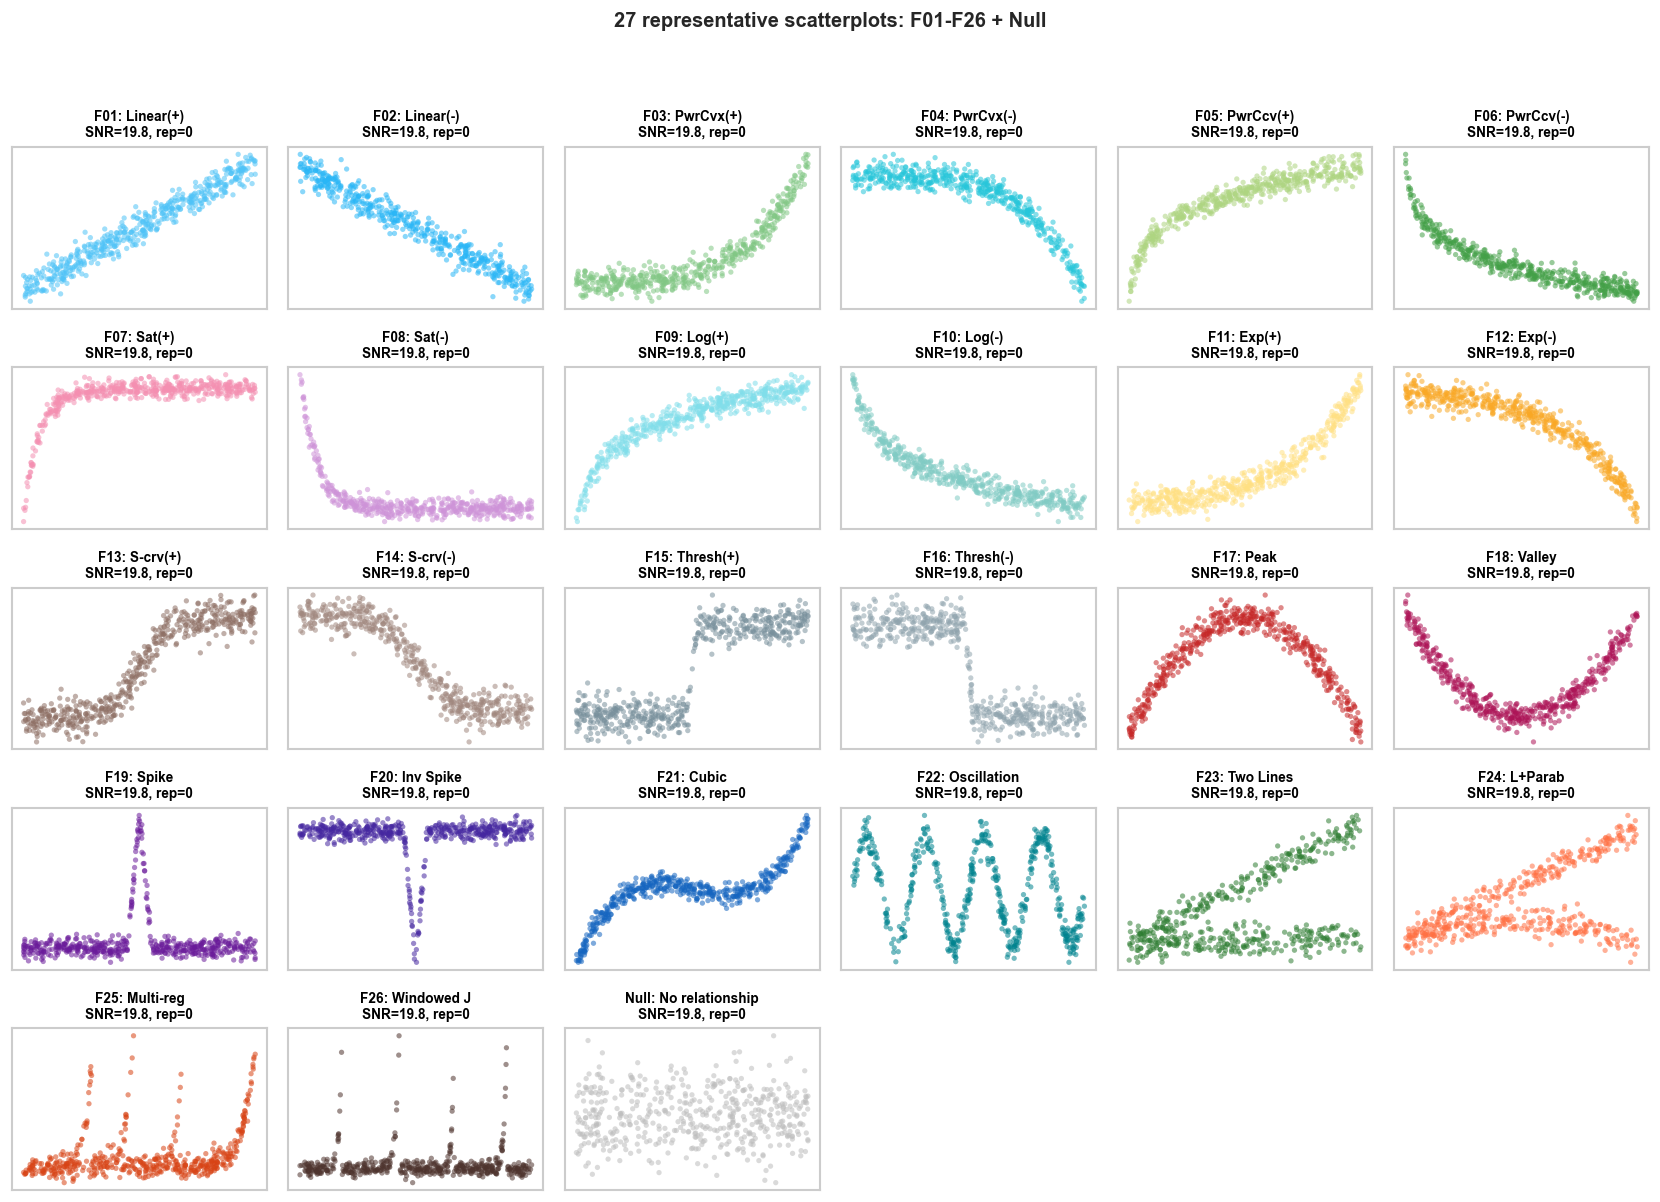

In [6]:
# ── Plot 1: raw 27 representative scatterplots ──
pts = np.load(S1_DIR / 'scatter_points.npz')
x_all, y_all = pts['x'], pts['y']

# scatter_points.npz follows the full cases.csv row order, not the filtered df order.
case_idx_by_id = pd.Series(np.arange(len(cases_full)), index=cases_full['case_id']).to_dict()

fig, axes = plt.subplots(5, 6, figsize=(14, 10))
fig.suptitle('27 representative scatterplots: F01-F26 + Null',
             fontsize=12, fontweight='bold', y=1.0)

for ax, (_, row) in zip(axes.flat, cases_27.iterrows()):
    idx = case_idx_by_id.get(row['case_id'])
    color = FAMILY_PALETTE.get(row['family_id'], '#5b9bd5')
    if idx is not None:
        ax.scatter(x_all[idx], y_all[idx], s=10, alpha=0.55,
                   color=color, edgecolors='none')
    ax.set_title(
        f"{row['family_id']}: {row['short']}\nSNR={row['snr_val']:.3g}, rep={int(row['replicate'])}",
        fontsize=8.2, fontweight='bold', color='black'
    )
    ax.set_xticks([])
    ax.set_yticks([])

for ax in axes.flat[len(cases_27):]:
    ax.set_visible(False)

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()




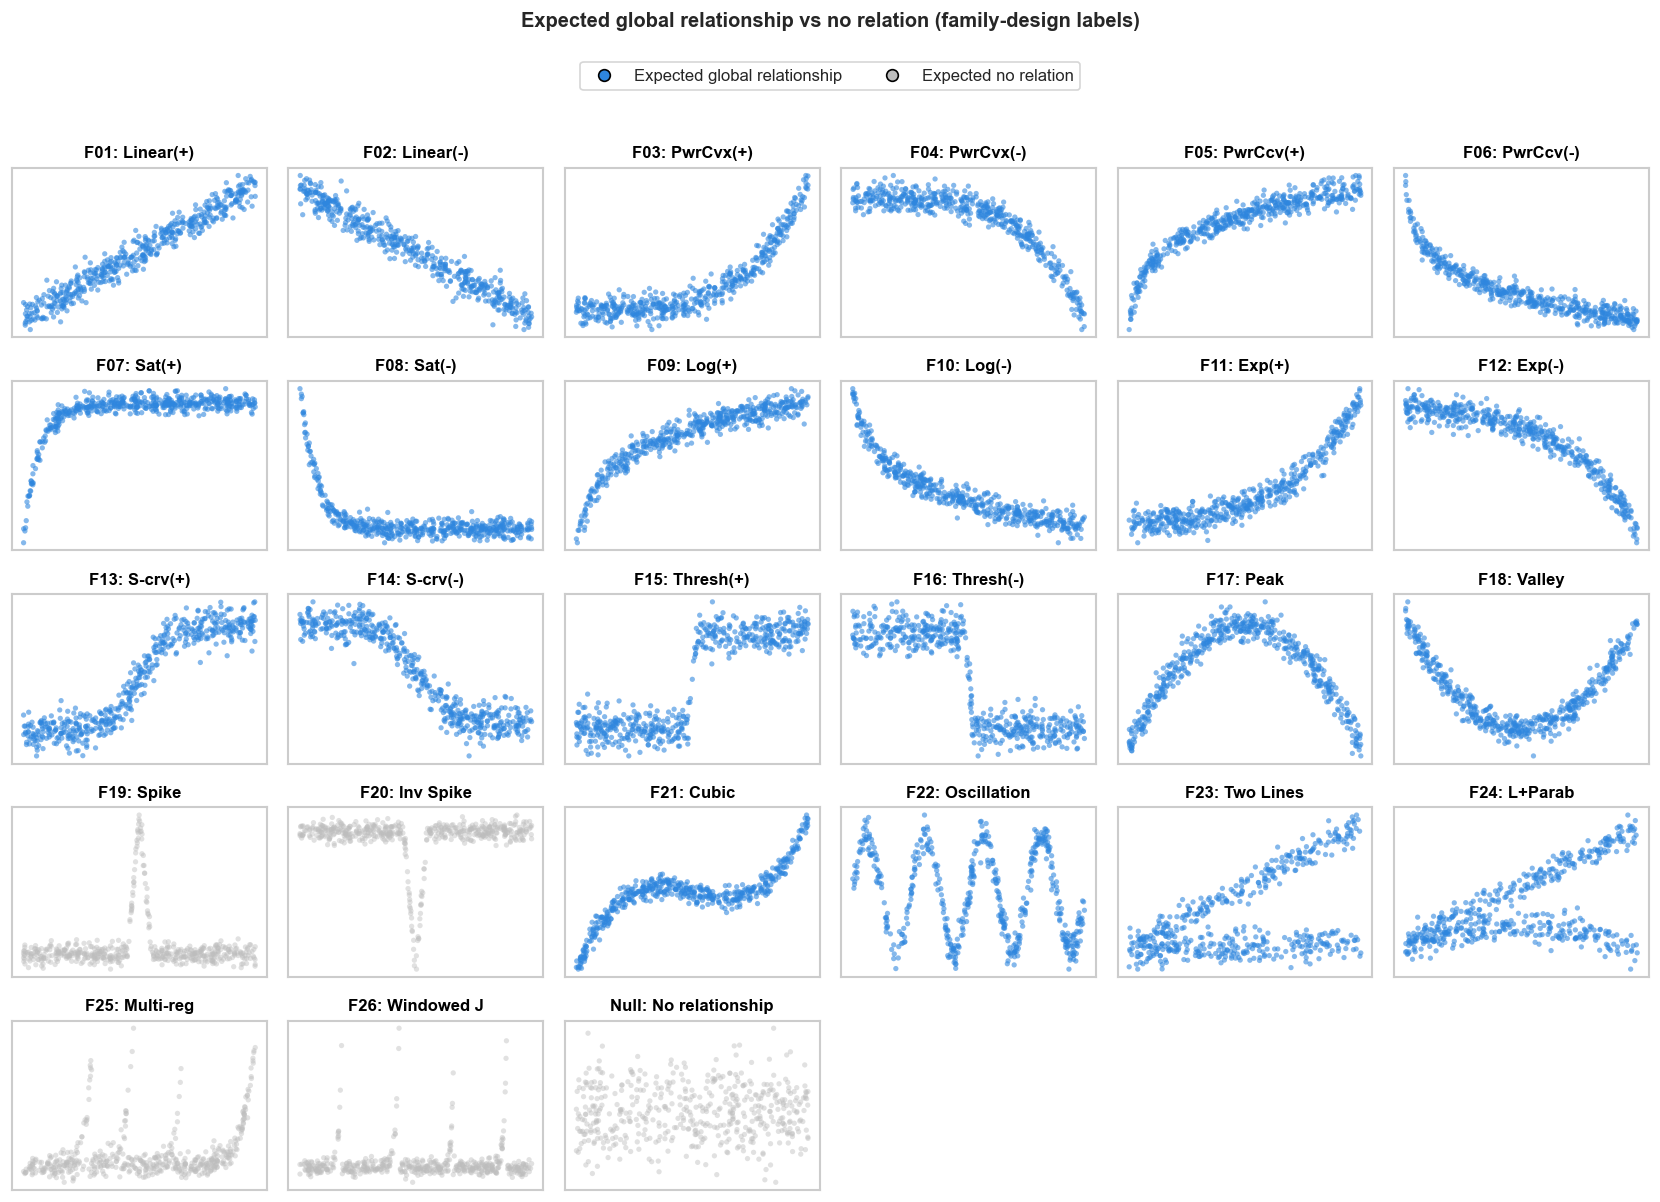

Expected no relation: ['F19', 'F20', 'F25', 'F26', 'Null']
Expected global relationship: ['F01', 'F02', 'F03', 'F04', 'F05', 'F06', 'F07', 'F08', 'F09', 'F10', 'F11', 'F12', 'F13', 'F14', 'F15', 'F16', 'F17', 'F18', 'F21', 'F22', 'F23', 'F24']


In [7]:
# ── Expected map 1: global relationship vs no relation ──
# Expected labels from family design, before applying MIC/dcor detection.
EXPECTED_NO_REL_FIDS = {'F19', 'F20', 'F25', 'F26', 'Null'}
EXPECTED_GLOBAL_FIDS = set(FAMILY_IDS_27) - EXPECTED_NO_REL_FIDS

cases_27['expected_global_label'] = np.where(
    cases_27['family_id'].isin(EXPECTED_NO_REL_FIDS),
    'Expected no relation',
    'Expected global relationship'
)

EXPECTED_GLOBAL_COLORS = {
    'Expected global relationship': '#2E86DE',
    'Expected no relation': '#BDBDBD',
}

if 'x_all' not in globals() or 'y_all' not in globals():
    pts = np.load(S1_DIR / 'scatter_points.npz')
    x_all, y_all = pts['x'], pts['y']

if 'case_idx_by_id' not in globals():
    case_idx_by_id = pd.Series(np.arange(len(cases_full)), index=cases_full['case_id']).to_dict()

fig, axes = plt.subplots(5, 6, figsize=(14, 10))
fig.suptitle('Expected global relationship vs no relation (family-design labels)',
             fontsize=12, fontweight='bold', y=1.0)

for ax, (_, row) in zip(axes.flat, cases_27.iterrows()):
    idx = case_idx_by_id.get(row['case_id'])
    label = row['expected_global_label']
    color = EXPECTED_GLOBAL_COLORS[label]
    alpha = 0.58 if label == 'Expected global relationship' else 0.45

    if idx is not None:
        ax.scatter(x_all[idx], y_all[idx], s=10, alpha=alpha,
                   color=color, edgecolors='none')

    ax.set_title(
        f"{row['family_id']}: {row['short']}",
        fontsize=10.0, fontweight='bold', color='black'
    )
    ax.set_xticks([])
    ax.set_yticks([])

for ax in axes.flat[len(cases_27):]:
    ax.set_visible(False)

handles = [Line2D([0], [0], marker='o', color='none', markerfacecolor=c,
                  markersize=7, label=k) for k, c in EXPECTED_GLOBAL_COLORS.items()]
fig.legend(handles=handles, loc='upper center', ncol=2,
           fontsize=10, frameon=True, bbox_to_anchor=(0.5, 0.965))

plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.show()

print('Expected no relation:', sorted(EXPECTED_NO_REL_FIDS))
print('Expected global relationship:', sorted(EXPECTED_GLOBAL_FIDS))


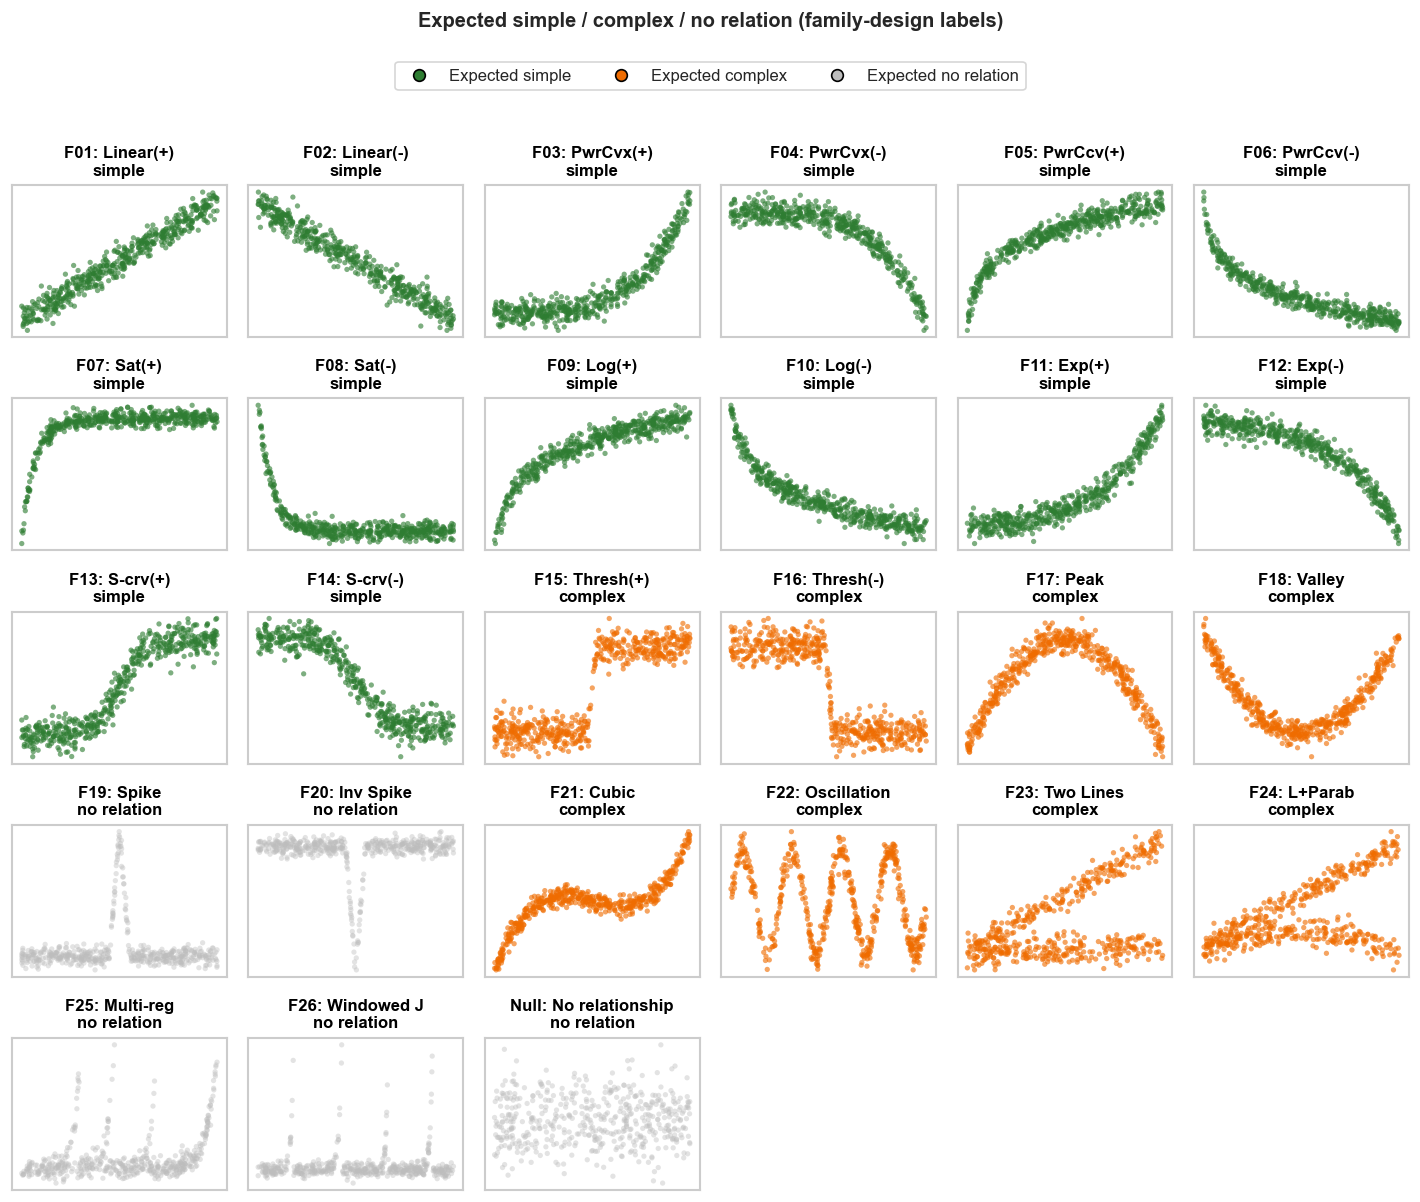

,family_id,short,expected_global_label,expected_tree_label
0,F01,Linear(+),Expected global relationship,Expected simple
1,F02,Linear(-),Expected global relationship,Expected simple
2,F03,PwrCvx(+),Expected global relationship,Expected simple
3,F04,PwrCvx(-),Expected global relationship,Expected simple
4,F05,PwrCcv(+),Expected global relationship,Expected simple
5,F06,PwrCcv(-),Expected global relationship,Expected simple
6,F07,Sat(+),Expected global relationship,Expected simple
7,F08,Sat(-),Expected global relationship,Expected simple
8,F09,Log(+),Expected global relationship,Expected simple
9,F10,Log(-),Expected global relationship,Expected simple


In [8]:
# ── Expected map 2: simple vs complex on the expected global map ──
# Simple relationship = single-regime, continuous, monotonic dominant trend.
# Complex relationship = non-monotone, multi-regime, branching, oscillation, threshold, or structural change.
EXPECTED_SIMPLE_FIDS = {
    'F01', 'F02', 'F03', 'F04', 'F05', 'F06', 'F07', 'F08',
    'F09', 'F10', 'F11', 'F12', 'F13', 'F14',
}
EXPECTED_COMPLEX_FIDS = {'F15', 'F16', 'F17', 'F18', 'F21', 'F22', 'F23', 'F24'}
EXPECTED_NO_REL_FIDS = {'F19', 'F20', 'F25', 'F26', 'Null'}

cases_27['expected_tree_label'] = np.select(
    [
        cases_27['family_id'].isin(EXPECTED_SIMPLE_FIDS),
        cases_27['family_id'].isin(EXPECTED_COMPLEX_FIDS),
        cases_27['family_id'].isin(EXPECTED_NO_REL_FIDS),
    ],
    ['Expected simple', 'Expected complex', 'Expected no relation'],
    default='Expected unassigned'
)

EXPECTED_TREE_COLORS = {
    'Expected simple': '#2E7D32',
    'Expected complex': '#EF6C00',
    'Expected no relation': '#BDBDBD',
    'Expected unassigned': '#757575',
}

if 'x_all' not in globals() or 'y_all' not in globals():
    pts = np.load(S1_DIR / 'scatter_points.npz')
    x_all, y_all = pts['x'], pts['y']

if 'case_idx_by_id' not in globals():
    case_idx_by_id = pd.Series(np.arange(len(cases_full)), index=cases_full['case_id']).to_dict()

fig, axes = plt.subplots(5, 6, figsize=(12, 10))
fig.suptitle('Expected simple / complex / no relation (family-design labels)',
             fontsize=12, fontweight='bold', y=1.0)

for ax, (_, row) in zip(axes.flat, cases_27.iterrows()):
    idx = case_idx_by_id.get(row['case_id'])
    label = row['expected_tree_label']
    color = EXPECTED_TREE_COLORS[label]
    alpha = 0.62 if label != 'Expected no relation' else 0.42

    if idx is not None:
        ax.scatter(x_all[idx], y_all[idx], s=10, alpha=alpha,
                   color=color, edgecolors='none')

    ax.set_title(
        f"{row['family_id']}: {row['short']}\n{label.replace('Expected ', '')}",
        fontsize=10, fontweight='bold', color='black'
    )
    ax.set_xticks([])
    ax.set_yticks([])

for ax in axes.flat[len(cases_27):]:
    ax.set_visible(False)

handles = [Line2D([0], [0], marker='o', color='none', markerfacecolor=c,
                  markersize=7, label=k) for k, c in EXPECTED_TREE_COLORS.items()
           if k in set(cases_27['expected_tree_label'])]
fig.legend(handles=handles, loc='upper center', ncol=3,
           fontsize=10, frameon=True, bbox_to_anchor=(0.5, 0.965))

plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.show()

display(cases_27[['family_id', 'short', 'expected_global_label', 'expected_tree_label']])


## Step 1 — Global Relationship

`MIC >= threshold AND distance_correlation >= threshold`

Null is kept as its own baseline category.

In [9]:
# ── Step 1: Global Relationship ──
MIC_THRESH = 0.8
DCOR_THRESH = 0

cases_27['pass_MIC'] = cases_27['MIC'] >= MIC_THRESH
cases_27['pass_dcor'] = cases_27['distance_correlation'] >= DCOR_THRESH
cases_27['global_relationship'] = (
    (cases_27['family_id'] != 'Null') &
    cases_27['pass_MIC'] &
    cases_27['pass_dcor']
)

cases_27['global_label'] = np.where(
    cases_27['family_id'] == 'Null',
    'Null',
    np.where(cases_27['global_relationship'], 'Global relationship', 'No global relationship')
)

global_cases = cases_27[cases_27['global_relationship']].copy()

print('═══ Step 1: Global Relationship ═══')
print(f'Rule: MIC >= {MIC_THRESH} AND dcor >= {DCOR_THRESH}')
print(f'Global relationship: {len(global_cases)} / 26 signal families')
print()
print(cases_27['global_label'].value_counts().to_string())

display(cases_27[[
    'family_id', 'short', 'MIC', 'distance_correlation',
    'pass_MIC', 'pass_dcor', 'global_label',
]].round(3))

═══ Step 1: Global Relationship ═══
Rule: MIC >= 0.8 AND dcor >= 0
Global relationship: 16 / 26 signal families

global_label
Global relationship       16
No global relationship    10
Null                       1


,family_id,short,MIC,distance_correlation,pass_MIC,pass_dcor,global_label
0,F01,Linear(+),0.950,0.972,True,True,Global relationship
1,F02,Linear(-),0.988,0.974,True,True,Global relationship
2,F03,PwrCvx(+),0.834,0.884,True,True,Global relationship
3,F04,PwrCvx(-),0.790,0.857,False,True,No global relationship
4,F05,PwrCcv(+),0.885,0.932,True,True,Global relationship
5,F06,PwrCcv(-),0.895,0.931,True,True,Global relationship
6,F07,Sat(+),0.558,0.629,False,True,No global relationship
7,F08,Sat(-),0.527,0.603,False,True,No global relationship
8,F09,Log(+),0.846,0.927,True,True,Global relationship
9,F10,Log(-),0.879,0.925,True,True,Global relationship


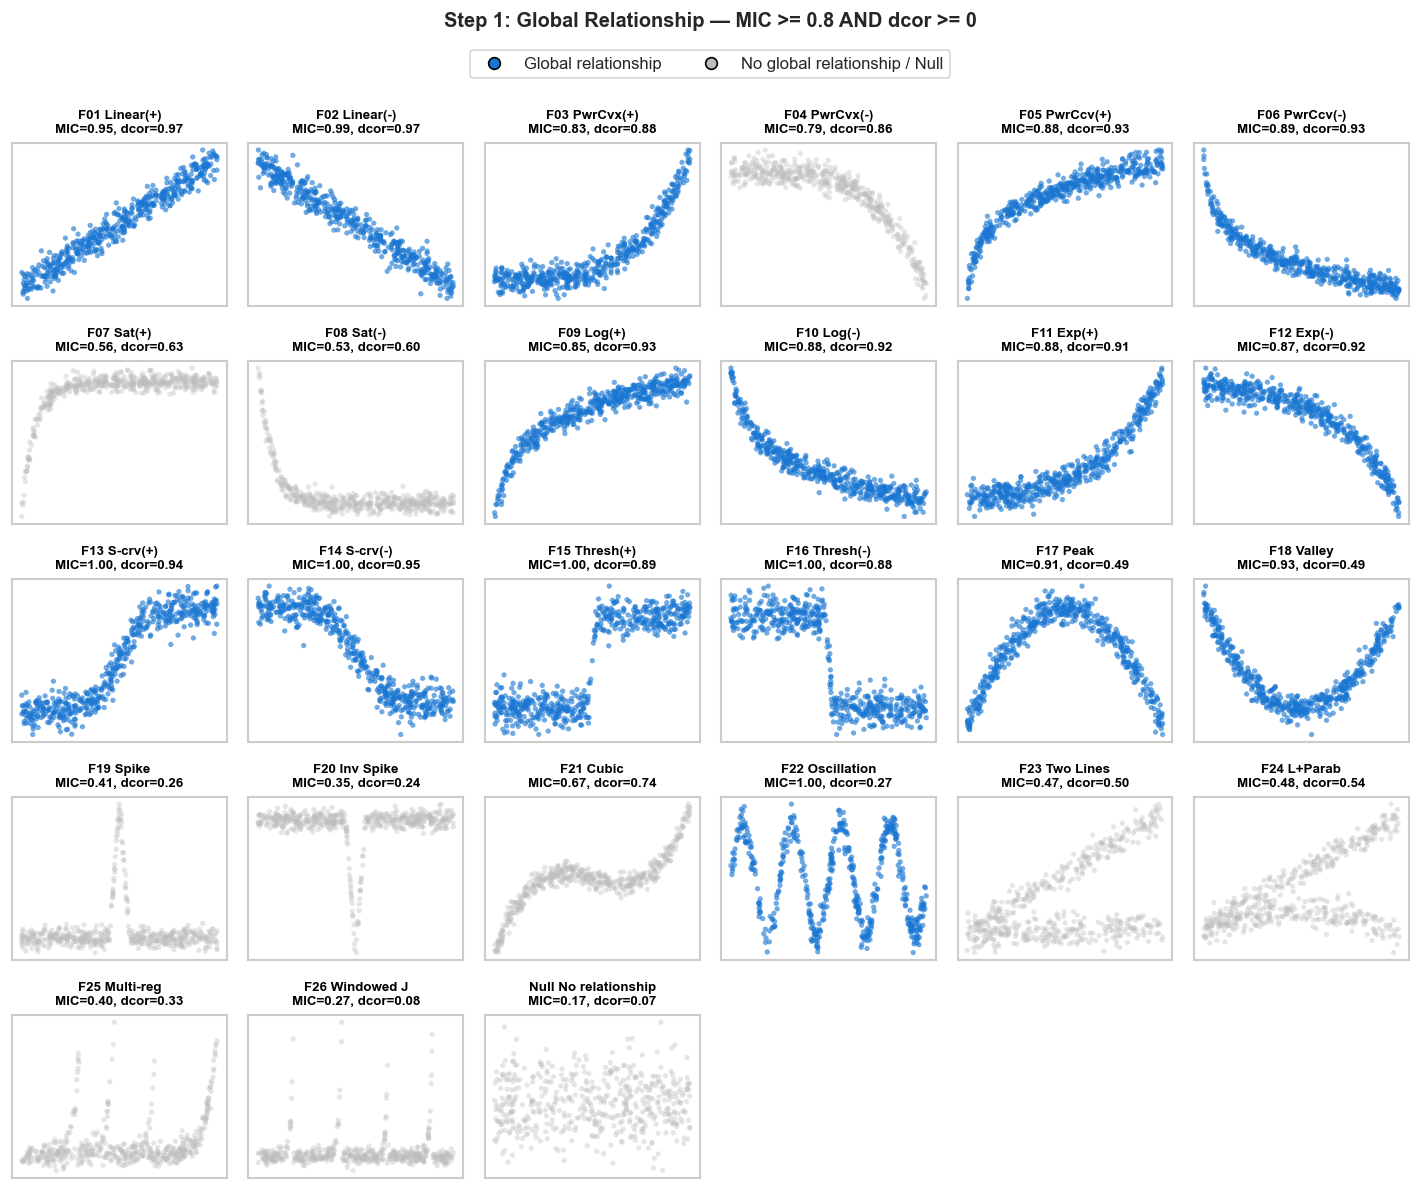

In [10]:
# ── Plot Step 1: Global relationship ──
if 'x_all' not in globals() or 'y_all' not in globals():
    pts = np.load(S1_DIR / 'scatter_points.npz')
    x_all, y_all = pts['x'], pts['y']

if 'case_idx_by_id' not in globals():
    case_idx_by_id = pd.Series(np.arange(len(cases_full)), index=cases_full['case_id']).to_dict()

fig, axes = plt.subplots(5, 6, figsize=(12, 10))
fig.suptitle(f'Step 1: Global Relationship — MIC >= {MIC_THRESH} AND dcor >= {DCOR_THRESH}',
             fontsize=12, fontweight='bold', y=0.99)

for ax, (_, row) in zip(axes.flat, cases_27.iterrows()):
    idx = case_idx_by_id.get(row['case_id'])
    is_global = bool(row['global_relationship'])
    color = C_GLOBAL if is_global else C_NO_REL
    alpha = 0.62 if is_global else 0.38

    if idx is not None:
        ax.scatter(x_all[idx], y_all[idx], s=10, alpha=alpha,
                   color=color, edgecolors='none')

    ax.set_title(
        f"{row['family_id']} {row['short']}\nMIC={row['MIC']:.2f}, dcor={row['distance_correlation']:.2f}",
        fontsize=8.0, fontweight='bold', color='black')
    ax.set_xticks([]); ax.set_yticks([])

for ax in axes.flat[len(cases_27):]:
    ax.set_visible(False)

handles = [
    Line2D([0],[0], marker='o', color='none', markerfacecolor=C_GLOBAL, markersize=7, label='Global relationship'),
    Line2D([0],[0], marker='o', color='none', markerfacecolor=C_NO_REL, markersize=7, label='No global relationship / Null'),
]
fig.legend(handles=handles, loc='upper center', ncol=2, fontsize=10, frameon=True, bbox_to_anchor=(0.5, 0.965))
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

In [11]:
# (Removed: duplicate Step 1 plot)

## Step 2 — Simple vs Complex

Run only on cases that passed Step 1.

Base: `|ρ| >= 0.7 AND |r| >= 0.7`
Optional gates (toggleable):
- `MAS < 0.10` — non-monotonicity filter
- `MIC-r² < 0.20` — non-linearity filter (catches threshold-type)
- **Slope sign-change gate** — bin raw scatter data into N bins, compute slope per bin, count adjacent sign changes (with prominence filter).
  - `N_SLOPE_BINS`: number of bins (default 5)
  - `BIN_MODE`: `equal_count` (quantile) or `equal_width`
  - `MAX_SIGN_CHANGES`: max allowed sign changes (default 0 = strict)
  - `USE_PROMINENCE_FILTER`: toggle prominence filtering on/off
  - `MIN_REVERSAL_PROMINENCE`: minimum `|slope_right| / |slope_left|` for a sign change to count (default 0.1). Compares with left neighbor.

In [12]:
# ── Step 2: Simple vs Complex ──
R_THRESH = 0.7

USE_REV_GATE = False
REVERSAL_PROMINENCE = 0.10

USE_MAS_GATE = False
MAS_THRESH = 0.10

USE_MR_GATE = False
MR_THRESH = 0.20

USE_SIGN_CHANGE_GATE = True
MAX_SIGN_CHANGES = 1          # 0 = strict (no turning point allowed)
N_SLOPE_BINS = 3              # number of bins for slope computation
BIN_MODE = 'equal_count'      # 'equal_count' (quantile) or 'equal_width'
USE_PROMINENCE_FILTER = False  # filter out noise sign changes by neighbor ratio
MIN_REVERSAL_PROMINENCE = 0.1 # |slope_right| / |slope_left| must exceed this

def compute_reversal_prominence(frame):
    e = frame['standardized_polyfit_early_slope'].to_numpy(dtype=float)
    m = frame['standardized_polyfit_middle_slope'].to_numpy(dtype=float)
    l = frame['standardized_polyfit_late_slope'].to_numpy(dtype=float)

    sign_e, sign_m, sign_l = np.sign(e), np.sign(m), np.sign(l)
    has_sign_change = ~((sign_e == sign_m) & (sign_m == sign_l))

    abs_max = np.maximum(np.maximum(np.abs(e), np.abs(m)), np.abs(l))
    abs_max = np.where(abs_max == 0, 1, abs_max)
    maj_sign = np.sign(e + m + l)

    rev_prom = np.zeros(len(frame))
    for i in range(len(frame)):
        if not has_sign_change[i] or maj_sign[i] == 0:
            continue
        rev_vals = [abs(s) for s in [e[i], m[i], l[i]]
                    if np.sign(s) != maj_sign[i] and np.sign(s) != 0]
        if rev_vals:
            rev_prom[i] = max(rev_vals) / abs_max[i]
    return rev_prom, has_sign_change

sc = global_cases.copy()
sc['pass_spearman'] = sc['spearman_rho'].abs() >= R_THRESH
sc['pass_pearson'] = sc['pearson_r'].abs() >= R_THRESH

sc['pass_MAS'] = sc['MAS'] < MAS_THRESH if USE_MAS_GATE else True
sc['pass_MR'] = sc['MIC_minus_r2'] < MR_THRESH if USE_MR_GATE else True

# ── Binned slope sign-change detection (from raw scatter data) ──
if USE_SIGN_CHANGE_GATE:
    _pts = np.load(S1_DIR / 'scatter_points.npz')
    _x_raw, _y_raw = _pts['x'], _pts['y']
    _cidx = pd.Series(np.arange(len(cases_full)), index=cases_full['case_id']).to_dict()
    _idx = np.array([_cidx[cid] for cid in sc['case_id'].values])
    _x = _x_raw[_idx]
    _y = _y_raw[_idx]

    _srt = np.argsort(_x, axis=1)
    _xs = np.take_along_axis(_x, _srt, axis=1)
    _ys = np.take_along_axis(_y, _srt, axis=1)
    n_pts = _xs.shape[1]

    bin_slopes = np.zeros((len(sc), N_SLOPE_BINS))

    if BIN_MODE == 'equal_count':
        edges = np.linspace(0, n_pts, N_SLOPE_BINS + 1, dtype=int)
        for b in range(N_SLOPE_BINS):
            xb = _xs[:, edges[b]:edges[b+1]]
            yb = _ys[:, edges[b]:edges[b+1]]
            nb = edges[b+1] - edges[b]
            sx  = xb.sum(axis=1)
            sy  = yb.sum(axis=1)
            sxy = (xb * yb).sum(axis=1)
            sx2 = (xb ** 2).sum(axis=1)
            denom = nb * sx2 - sx ** 2
            denom = np.where(denom == 0, 1, denom)
            bin_slopes[:, b] = (nb * sxy - sx * sy) / denom
    else:  # equal_width
        _xmin = _xs[:, [0]]
        _xrng = _xs[:, [-1]] - _xmin
        _xrng = np.where(_xrng == 0, 1, _xrng)
        _xn = (_xs - _xmin) / _xrng
        for b in range(N_SLOPE_BINS):
            lo = b / N_SLOPE_BINS
            hi = (b + 1) / N_SLOPE_BINS
            mask = (_xn >= lo) & (_xn < hi) if b < N_SLOPE_BINS - 1 else (_xn >= lo)
            nb  = mask.sum(axis=1).astype(float)
            sx  = np.where(mask, _xs, 0).sum(axis=1)
            sy  = np.where(mask, _ys, 0).sum(axis=1)
            sxy = np.where(mask, _xs * _ys, 0).sum(axis=1)
            sx2 = np.where(mask, _xs ** 2, 0).sum(axis=1)
            denom = nb * sx2 - sx ** 2
            valid = (nb >= 2) & (denom != 0)
            denom = np.where(valid, denom, 1)
            bin_slopes[:, b] = np.where(valid, (nb * sxy - sx * sy) / denom, 0)

    signs = np.sign(bin_slopes)
    sign_diffs = np.diff(signs, axis=1)
    has_change = sign_diffs != 0

    # Prominence filter: compare with left neighbor
    if USE_PROMINENCE_FILTER:
        abs_left  = np.abs(bin_slopes[:, :-1])
        abs_right = np.abs(bin_slopes[:, 1:])
        abs_left_safe = np.where(abs_left == 0, 1, abs_left)
        prominent = (abs_right / abs_left_safe) >= MIN_REVERSAL_PROMINENCE
    else:
        prominent = np.ones_like(has_change, dtype=bool)

    n_sign_changes = (has_change & prominent).sum(axis=1)
    sc['n_sign_changes'] = n_sign_changes
    sc['pass_sign_change'] = n_sign_changes <= MAX_SIGN_CHANGES

    del _pts, _x_raw, _y_raw, _x, _y, _xs, _ys
    prom_label = f', prom≥{MIN_REVERSAL_PROMINENCE} (neighbor)' if USE_PROMINENCE_FILTER else ''
    print(f'  Sign-change gate: {N_SLOPE_BINS} bins, mode={BIN_MODE}, max_changes={MAX_SIGN_CHANGES}{prom_label}')
else:
    sc['pass_sign_change'] = True
    sc['n_sign_changes'] = 0

rev_prom, has_sign_change = compute_reversal_prominence(sc)
sc['has_slope_sign_change'] = has_sign_change
sc['reversal_prominence'] = rev_prom
if USE_REV_GATE:
    sc['pass_no_reversal'] = ~(sc['has_slope_sign_change'] & (sc['reversal_prominence'] >= REVERSAL_PROMINENCE))
else:
    sc['pass_no_reversal'] = True

sc['is_simple'] = sc['pass_spearman'] & sc['pass_pearson'] & sc['pass_MAS'] & sc['pass_MR'] & sc['pass_sign_change'] & sc['pass_no_reversal']

cases_27 = cases_27.merge(
    sc[['case_id', 'pass_spearman', 'pass_pearson', 'pass_MAS', 'pass_MR',
        'n_sign_changes', 'pass_sign_change',
        'has_slope_sign_change', 'reversal_prominence', 'pass_no_reversal', 'is_simple']],
    on='case_id', how='left'
)

cases_27['simple_complex_label'] = np.select(
    [cases_27['family_id'] == 'Null',
     ~cases_27['global_relationship'],
     cases_27['is_simple'].fillna(False)],
    ['Null', 'No global relationship', 'Simple'],
    default='Complex'
)

rule_parts = [f'|ρ| ≥ {R_THRESH}', f'|r| ≥ {R_THRESH}']
if USE_MAS_GATE: rule_parts.append(f'MAS < {MAS_THRESH}')
if USE_MR_GATE:  rule_parts.append(f'MIC-r² < {MR_THRESH}')
if USE_SIGN_CHANGE_GATE:
    sc_desc = f'sign_changes ≤ {MAX_SIGN_CHANGES} ({N_SLOPE_BINS}bins, {BIN_MODE}'
    if USE_PROMINENCE_FILTER:
        sc_desc += f', prom≥{MIN_REVERSAL_PROMINENCE}'
    sc_desc += ')'
    rule_parts.append(sc_desc)
if USE_REV_GATE: rule_parts.append(f'RevProm < {REVERSAL_PROMINENCE}')
rule_str = ' AND '.join(rule_parts)

print('═══ Step 2: Simple vs Complex ═══')
print(f'Rule: {rule_str}')
print(f'Gates: MAS={USE_MAS_GATE}, MIC-r²={USE_MR_GATE}, sign_change={USE_SIGN_CHANGE_GATE}, prominence={USE_PROMINENCE_FILTER}, Reversal={USE_REV_GATE}')
print()
print(cases_27['simple_complex_label'].value_counts().to_string())

display(cases_27[[
    'family_id', 'short', 'global_label', 'spearman_rho', 'pearson_r', 'MAS', 'MIC_minus_r2',
    'standardized_polyfit_early_slope', 'standardized_polyfit_middle_slope',
    'standardized_polyfit_late_slope', 'reversal_prominence',
    'n_sign_changes', 'pass_sign_change',
    'pass_spearman', 'pass_pearson', 'pass_MAS', 'pass_MR', 'pass_no_reversal',
    'simple_complex_label',
]].round(3))

  Sign-change gate: 3 bins, mode=equal_count, max_changes=1
═══ Step 2: Simple vs Complex ═══
Rule: |ρ| ≥ 0.7 AND |r| ≥ 0.7 AND sign_changes ≤ 1 (3bins, equal_count)
Gates: MAS=False, MIC-r²=False, sign_change=True, prominence=False, Reversal=False

simple_complex_label
Simple                    13
No global relationship    10
Complex                    3
Null                       1


,family_id,short,global_label,spearman_rho,pearson_r,MAS,MIC_minus_r2,standardized_polyfit_early_slope,standardized_polyfit_middle_slope,standardized_polyfit_late_slope,reversal_prominence,n_sign_changes,pass_sign_change,pass_spearman,pass_pearson,pass_MAS,pass_MR,pass_no_reversal,simple_complex_label
0,F01,Linear(+),Global relationship,0.977,0.976,0.041,-0.002,0.855,0.905,0.892,0.000,0.0,True,True,True,True,True,True,Simple
1,F02,Linear(-),Global relationship,-0.975,-0.976,0.041,0.036,-0.863,-0.838,-0.843,0.000,0.0,True,True,True,True,True,True,Simple
2,F03,PwrCvx(+),Global relationship,0.852,0.854,0.032,0.105,0.041,0.516,1.969,0.000,0.0,True,True,True,True,True,True,Simple
3,F04,PwrCvx(-),No global relationship,-0.850,-0.830,0.041,0.101,-0.065,-0.368,-1.815,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,No global relationship
4,F05,PwrCcv(+),Global relationship,0.951,0.906,0.029,0.063,1.423,0.532,0.310,0.000,0.0,True,True,True,True,True,True,Simple
5,F06,PwrCcv(-),Global relationship,-0.952,-0.898,0.036,0.089,-1.334,-0.402,-0.258,0.000,0.0,True,True,True,True,True,True,Simple
6,F07,Sat(+),No global relationship,0.583,0.574,0.099,0.229,1.775,0.004,-0.009,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,No global relationship
7,F08,Sat(-),No global relationship,-0.518,-0.564,0.037,0.208,-1.956,0.015,-0.016,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,No global relationship
8,F09,Log(+),Global relationship,0.941,0.903,0.033,0.030,1.427,0.504,0.297,0.000,0.0,True,True,True,True,True,True,Simple
9,F10,Log(-),Global relationship,-0.953,-0.894,0.030,0.080,-1.702,-0.488,-0.268,0.000,0.0,True,True,True,True,True,True,Simple


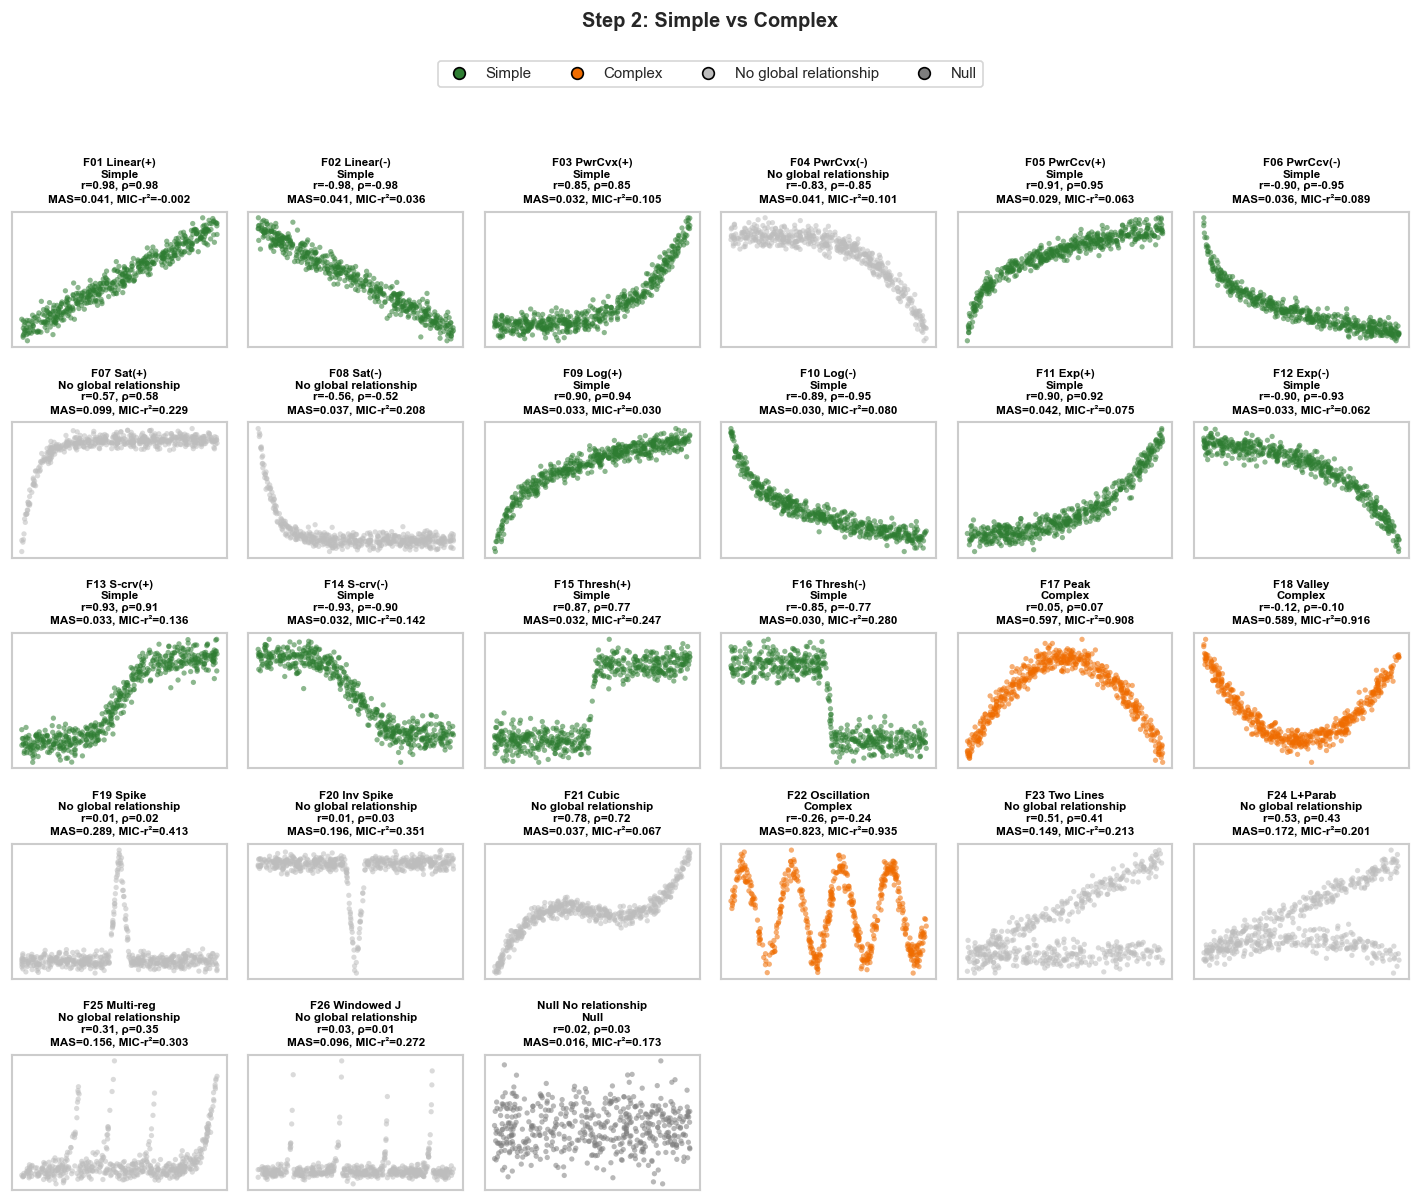

In [13]:
# ── Plot Step 2: Simple vs Complex ──
fig, axes = plt.subplots(5, 6, figsize=(12, 10))
fig.suptitle('Step 2: Simple vs Complex', fontsize=12, fontweight='bold', y=1.0)

SC_MAP = {'Simple': C_SIMPLE, 'Complex': C_COMPLEX, 'No global relationship': C_NO_REL, 'Null': C_NULL}

for ax, (_, row) in zip(axes.flat, cases_27.iterrows()):
    idx = case_idx_by_id.get(row['case_id'])
    label = row['simple_complex_label']
    color = SC_MAP[label]
    if idx is not None:
        ax.scatter(x_all[idx], y_all[idx], s=10, alpha=0.55, color=color, edgecolors='none')
    ax.set_title(
        f"{row['family_id']} {row['short']}\n{label}\n"
        f"r={row['pearson_r']:.2f}, ρ={row['spearman_rho']:.2f}\n"
        f"MAS={row['MAS']:.3f}, MIC-r²={row['MIC_minus_r2']:.3f}",
        fontsize=7.0, fontweight='bold', color='black')
    ax.set_xticks([]); ax.set_yticks([])

for ax in axes.flat[len(cases_27):]:
    ax.set_visible(False)

handles = [Line2D([0],[0], marker='o', color='none', markerfacecolor=v, markersize=7, label=k)
           for k, v in SC_MAP.items()]
fig.legend(handles=handles, loc='upper center', ncol=4, fontsize=9, frameon=True, bbox_to_anchor=(0.5, 0.965))
plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

## Step 3 — Direction

Sign of Pearson r. Only applies to Simple cases.

In [14]:
# ── Step 3: Direction ──
simple_cases_27 = cases_27[cases_27['simple_complex_label'] == 'Simple'].copy()

simple_cases_27['direction_tree'] = np.where(
    simple_cases_27['pearson_r'] > 0, 'Positive', 'Negative'
)

print('═══ Step 3: Direction (sign of Pearson r) ═══')
print(f'Simple cases: {len(simple_cases_27)}')
print()
print(simple_cases_27['direction_tree'].value_counts().to_string())
print()
display(simple_cases_27[['family_id', 'short', 'pearson_r', 'direction_tree']].round(3))

═══ Step 3: Direction (sign of Pearson r) ═══
Simple cases: 13

direction_tree
Positive    7
Negative    6



,family_id,short,pearson_r,direction_tree
0,F01,Linear(+),0.976,Positive
1,F02,Linear(-),-0.976,Negative
2,F03,PwrCvx(+),0.854,Positive
4,F05,PwrCcv(+),0.906,Positive
5,F06,PwrCcv(-),-0.898,Negative
8,F09,Log(+),0.903,Positive
9,F10,Log(-),-0.894,Negative
10,F11,Exp(+),0.898,Positive
11,F12,Exp(-),-0.899,Negative
12,F13,S-crv(+),0.930,Positive


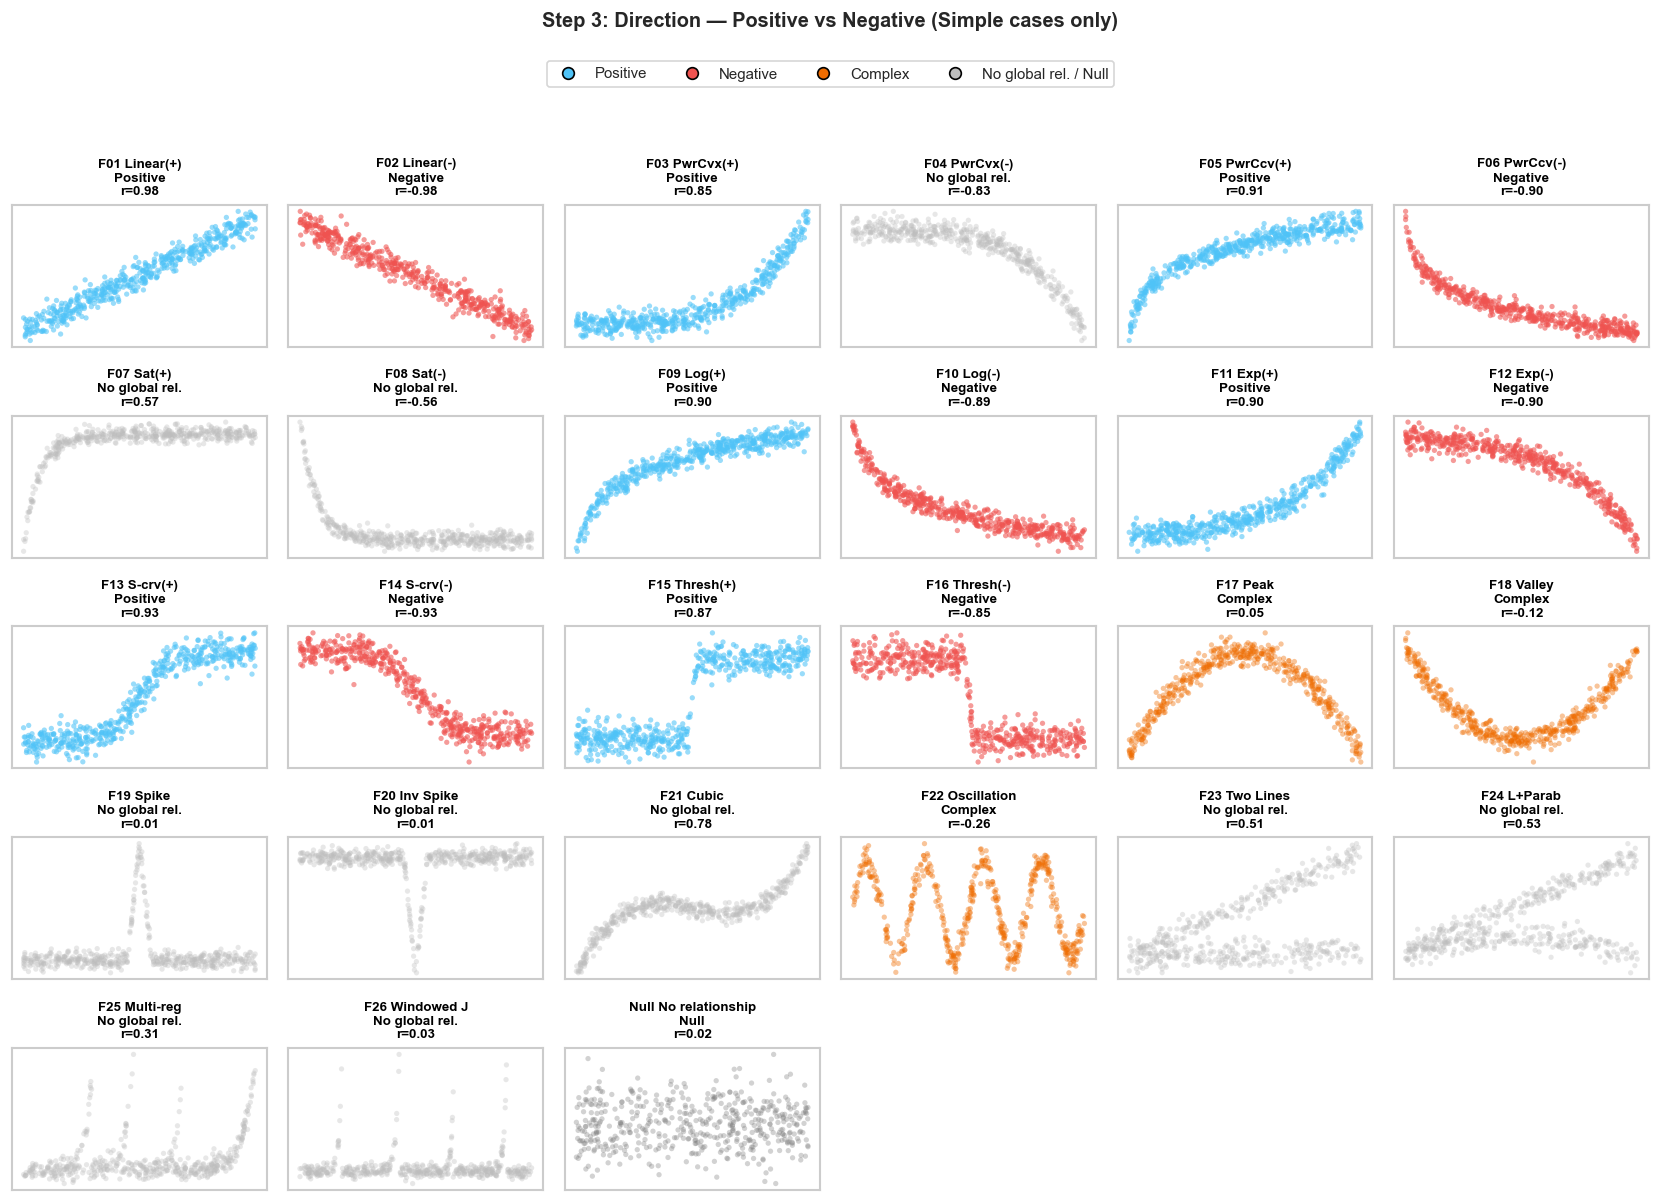

In [15]:
# ── Plot Step 3: Direction ──
cases_27 = cases_27.drop(columns=['direction_tree'], errors='ignore')
cases_27 = cases_27.merge(simple_cases_27[['case_id', 'direction_tree']], on='case_id', how='left')

fig, axes = plt.subplots(5, 6, figsize=(14, 10))
fig.suptitle('Step 3: Direction — Positive vs Negative (Simple cases only)',
             fontsize=12, fontweight='bold', y=1.0)

for ax, (_, row) in zip(axes.flat, cases_27.iterrows()):
    idx = case_idx_by_id.get(row['case_id'])
    if row['simple_complex_label'] == 'Simple':
        label = row['direction_tree']
        color = C_POS if label == 'Positive' else C_NEG
        alpha = 0.58
    elif row['simple_complex_label'] == 'Complex':
        label, color, alpha = 'Complex', C_COMPLEX, 0.40
    elif row['family_id'] == 'Null':
        label, color, alpha = 'Null', C_NULL, 0.35
    else:
        label, color, alpha = 'No global rel.', C_NO_REL, 0.35

    if idx is not None:
        ax.scatter(x_all[idx], y_all[idx], s=10, alpha=alpha, color=color, edgecolors='none')
    ax.set_title(f"{row['family_id']} {row['short']}\n{label}\nr={row['pearson_r']:.2f}",
                 fontsize=8.0, fontweight='bold', color='black')
    ax.set_xticks([]); ax.set_yticks([])

for ax in axes.flat[len(cases_27):]:
    ax.set_visible(False)

handles = [Line2D([0],[0], marker='o', color='none', markerfacecolor=c, markersize=7, label=k)
           for k, c in [('Positive', C_POS), ('Negative', C_NEG),
                         ('Complex', C_COMPLEX), ('No global rel. / Null', C_NO_REL)]]
fig.legend(handles=handles, loc='upper center', ncol=4, fontsize=9, frameon=True, bbox_to_anchor=(0.5, 0.965))
plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

## Step 4 — Monotonicity

|Spearman ρ| level: **Strong** (≥ 0.9) vs **Med** (< 0.9).
Optional gate: MAS < threshold (asymmetry filter).

In [16]:
# ── Step 4: Monotonicity ──
MONO_STRONG = 0.9

USE_MAS_GATE = False
MAS_THRESH = 0.20

cond_rho_strong = simple_cases_27['spearman_rho'].abs() >= MONO_STRONG
cond_mas = (simple_cases_27['MAS'] < MAS_THRESH) if USE_MAS_GATE else True

simple_cases_27['monotonicity_tree'] = np.where(
    cond_rho_strong & cond_mas, 'Strong', 'Med'
)

print(f'═══ Step 4: Monotonicity ═══')
rule_parts = [f'|ρ| ≥ {MONO_STRONG}']
if USE_MAS_GATE: rule_parts.append(f'MAS < {MAS_THRESH}')
print(f'Rule: Strong = {" AND ".join(rule_parts)}')
print(f'Gates: USE_MAS_GATE={USE_MAS_GATE}')
print()
print(simple_cases_27['monotonicity_tree'].value_counts().to_string())
print()
cols = ['family_id', 'short', 'spearman_rho', 'direction_tree', 'monotonicity_tree']
if USE_MAS_GATE: cols.insert(3, 'MAS')
display(simple_cases_27[cols].round(3))

═══ Step 4: Monotonicity ═══
Rule: Strong = |ρ| ≥ 0.9
Gates: USE_MAS_GATE=False

monotonicity_tree
Strong    10
Med        3



,family_id,short,spearman_rho,direction_tree,monotonicity_tree
0,F01,Linear(+),0.977,Positive,Strong
1,F02,Linear(-),-0.975,Negative,Strong
2,F03,PwrCvx(+),0.852,Positive,Med
4,F05,PwrCcv(+),0.951,Positive,Strong
5,F06,PwrCcv(-),-0.952,Negative,Strong
8,F09,Log(+),0.941,Positive,Strong
9,F10,Log(-),-0.953,Negative,Strong
10,F11,Exp(+),0.920,Positive,Strong
11,F12,Exp(-),-0.932,Negative,Strong
12,F13,S-crv(+),0.913,Positive,Strong


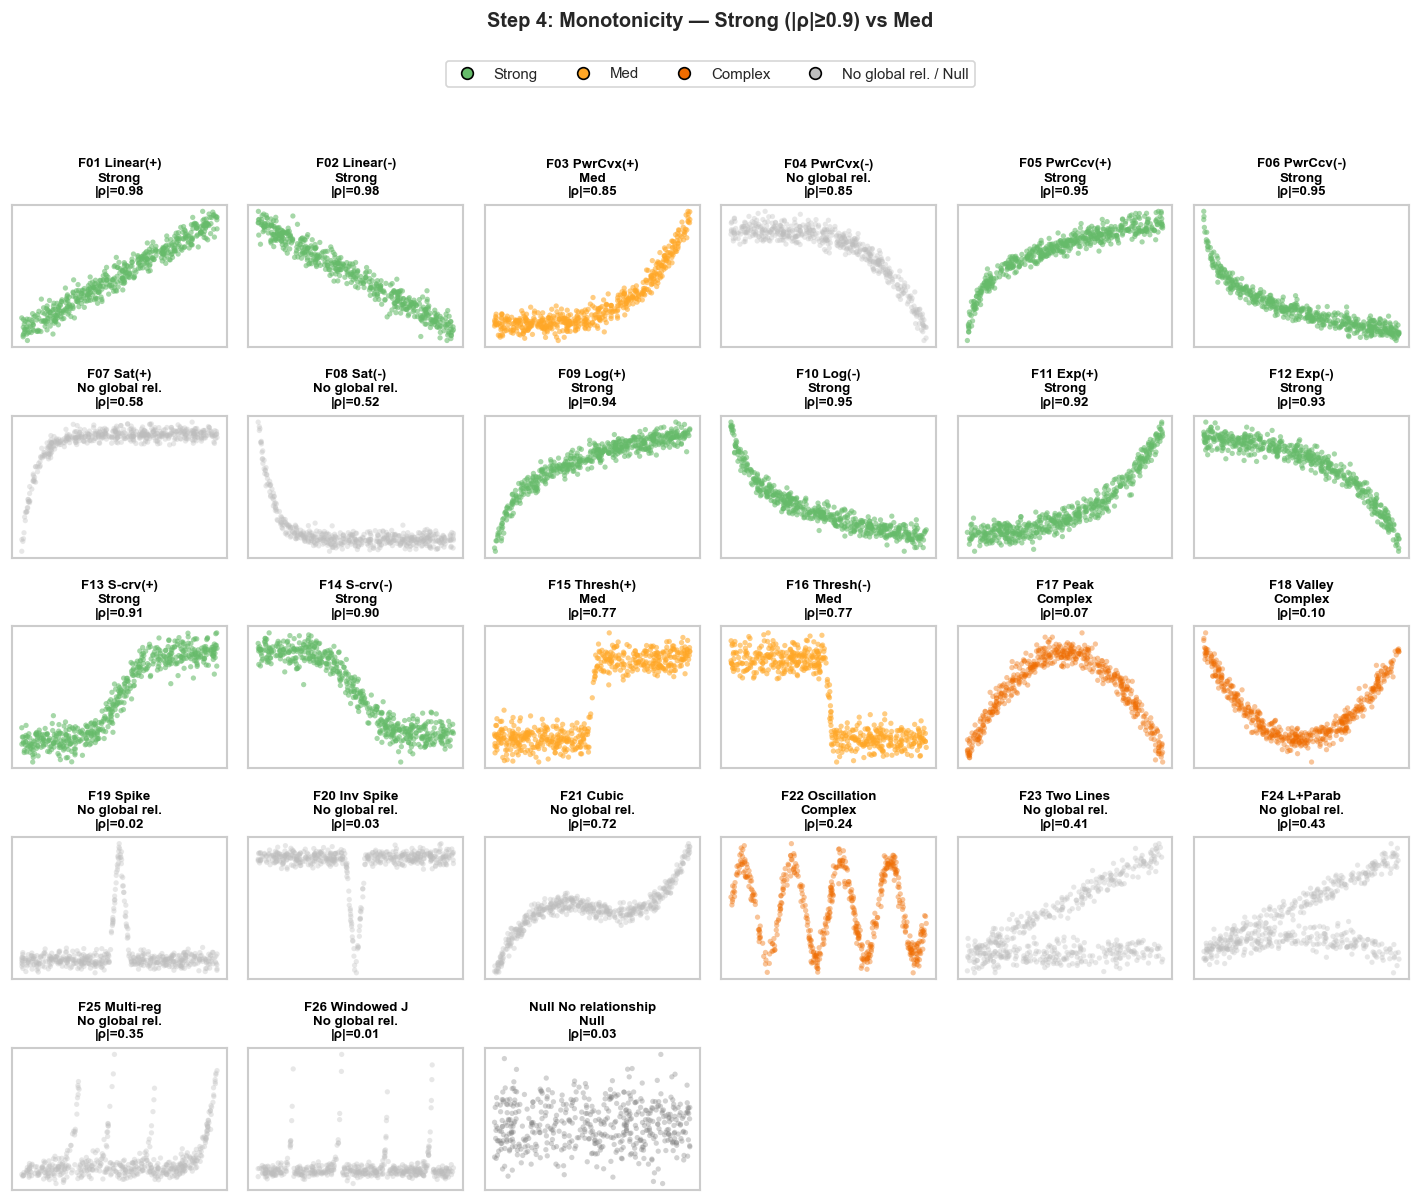

In [17]:
# ── Plot Step 4: Monotonicity ──
cases_27 = cases_27.drop(columns=['monotonicity_tree'], errors='ignore')
cases_27 = cases_27.merge(simple_cases_27[['case_id', 'monotonicity_tree']], on='case_id', how='left')

fig, axes = plt.subplots(5, 6, figsize=(12, 10))
fig.suptitle(f'Step 4: Monotonicity — Strong (|ρ|≥{MONO_STRONG}) vs Med',
             fontsize=12, fontweight='bold', y=1.0)

for ax, (_, row) in zip(axes.flat, cases_27.iterrows()):
    idx = case_idx_by_id.get(row['case_id'])
    if row['simple_complex_label'] == 'Simple':
        label = row['monotonicity_tree']
        color = C_MONO_S if label == 'Strong' else C_MONO_M
        alpha = 0.58
    elif row['simple_complex_label'] == 'Complex':
        label, color, alpha = 'Complex', C_COMPLEX, 0.40
    elif row['family_id'] == 'Null':
        label, color, alpha = 'Null', C_NULL, 0.35
    else:
        label, color, alpha = 'No global rel.', C_NO_REL, 0.35

    if idx is not None:
        ax.scatter(x_all[idx], y_all[idx], s=10, alpha=alpha, color=color, edgecolors='none')
    ax.set_title(f"{row['family_id']} {row['short']}\n{label}\n|ρ|={abs(row['spearman_rho']):.2f}",
                 fontsize=8.0, fontweight='bold', color='black')
    ax.set_xticks([]); ax.set_yticks([])

for ax in axes.flat[len(cases_27):]:
    ax.set_visible(False)

handles = [Line2D([0],[0], marker='o', color='none', markerfacecolor=c, markersize=7, label=k)
           for k, c in [('Strong', C_MONO_S), ('Med', C_MONO_M),
                         ('Complex', C_COMPLEX), ('No global rel. / Null', C_NO_REL)]]
fig.legend(handles=handles, loc='upper center', ncol=4, fontsize=9, frameon=True, bbox_to_anchor=(0.5, 0.965))
plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

## Polyfit Classification Functions

Global cubic polynomial fit → classify from f′(x) and f″(x) derivative patterns.

| f′(x) pattern | f″(x) pattern | Relationship Type |
|---|---|---|
| Maintains same sign | ≈ 0 | **Linear** |
| Maintains same sign | Constant positive | **Monotonic convex** |
| Maintains same sign | Constant negative | **Monotonic concave** |
| Maintains same sign | Changes sign once | **S-shaped / Inflected** |
| Changes sign once | Maintains same sign | **U-shaped / Inverted-U** |
| ≥ 2 sign changes | any | **Complex** → logistic fallback |

In [18]:
# ── Polyfit configuration ──
INTERIOR_MARGIN = 0.10
N_GRID = 200
DOMINANCE_THRESH = 0.75
LOGISTIC_R2_THRESH = 0.85


def _safe_logistic(x, L, k, x0, b):
    z = np.clip(-k * (x - x0), -500, 500)
    return L / (1.0 + np.exp(z)) + b


def _fit_logistic(xs, ys):
    x_range = xs[-1] - xs[0]
    n10 = max(1, len(xs) // 10)
    y_lo, y_hi = np.mean(ys[:n10]), np.mean(ys[-n10:])
    L0, b0, x0_0 = y_hi - y_lo, y_lo, np.median(xs)
    best_rss, best_popt = np.inf, None
    for k_scale in [3, 10, 40]:
        k0 = k_scale / (x_range + 1e-10)
        try:
            popt, _ = curve_fit(_safe_logistic, xs, ys, p0=[L0, k0, x0_0, b0], maxfev=2000)
            rss = np.sum((ys - _safe_logistic(xs, *popt)) ** 2)
            if rss < best_rss:
                best_rss, best_popt = rss, popt
        except Exception:
            pass
    return best_popt, best_rss


def _count_sign_changes(values):
    signs = np.sign(values).copy()
    for i in range(1, len(signs)):
        if signs[i] == 0:
            signs[i] = signs[i - 1]
    n = 0
    for i in range(1, len(signs)):
        if signs[i] != signs[i - 1] and signs[i] != 0 and signs[i - 1] != 0:
            n += 1
    return n


def _f2_dominance(f2):
    """Weighted fraction of |f''| on dominant side.
    > 0.75 means f'' is effectively constant-sign (zero-crossing at edge only).
    < 0.75 means f'' genuinely changes sign → inflected."""
    abs_f2 = np.abs(f2)
    total = np.sum(abs_f2)
    if total < 1e-10:
        return 1.0, 0
    frac_pos = np.sum(abs_f2[f2 > 0]) / total
    frac_neg = 1.0 - frac_pos
    return (frac_pos, 1) if frac_pos >= frac_neg else (frac_neg, -1)


def _classify_derivatives(f1, f2):
    """Classify shape from derivative patterns.

    f'(x) same sign + f''(x) ≈ 0           → linear
    f'(x) same sign + f''(x) constant pos   → convex
    f'(x) same sign + f''(x) constant neg   → concave
    f'(x) same sign + f''(x) changes sign   → inflected
    f'(x) changes sign once                  → U-shape / inverted-U
    f'(x) ≥ 2 sign changes                  → complex
    """
    max_f1 = np.max(np.abs(f1))
    max_f2 = np.max(np.abs(f2))
    n_f1_sign_changes = _count_sign_changes(f1)

    if n_f1_sign_changes == 0:
        # f' maintains same sign → monotonic branch
        if max_f2 < 0.05 * max_f1 and max_f1 > 1e-10:
            # f'' ≈ 0 → linear
            return 'linear'
        dominance, dom_sign = _f2_dominance(f2)
        if dominance >= DOMINANCE_THRESH:
            # f'' effectively constant sign → convex or concave
            return 'convex' if dom_sign > 0 else 'concave'
        else:
            # f'' changes sign → inflected / S-shaped
            return 'inflected'

    elif n_f1_sign_changes == 1:
        # f' changes sign once → U-shape or inverted-U
        mean_f2 = np.mean(f2)
        return 'U-shape' if mean_f2 > 0 else 'inverted-U'

    else:
        # f' ≥ 2 sign changes → complex
        return 'complex'


def polyfit_classify(x, y):
    order = np.argsort(x)
    xs, ys = x[order].astype(np.float64), y[order].astype(np.float64)
    ss_tot = np.sum((ys - ys.mean()) ** 2)

    coeffs3 = np.polyfit(xs, ys, 3)
    p = np.poly1d(coeffs3)
    pred3 = np.polyval(coeffs3, xs)
    r2_3 = 1.0 - np.sum((ys - pred3) ** 2) / ss_tot if ss_tot > 1e-30 else 0.0

    x_lo = xs[0] + INTERIOR_MARGIN * (xs[-1] - xs[0])
    x_hi = xs[-1] - INTERIOR_MARGIN * (xs[-1] - xs[0])
    x_grid = np.linspace(x_lo, x_hi, N_GRID)
    p1, p2 = np.polyder(p, 1), np.polyder(p, 2)
    f1, f2 = p1(x_grid), p2(x_grid)

    n_f1_sc = _count_sign_changes(f1)
    n_f2_sc = _count_sign_changes(f2)
    dominance, dom_sign = _f2_dominance(f2)

    shape = _classify_derivatives(f1, f2)

    logistic_used = False
    if shape == 'complex':
        popt, rss_log = _fit_logistic(xs, ys)
        if popt is not None:
            r2_log = 1.0 - rss_log / ss_tot if ss_tot > 1e-30 else 0.0
            x0_fit = popt[2]
            if r2_log > LOGISTIC_R2_THRESH and x_lo <= x0_fit <= x_hi:
                shape = 'inflected'
                logistic_used = True

    x_full = np.linspace(xs[0], xs[-1], N_GRID)
    return {
        'shape': shape, 'r2_3': r2_3, 'logistic_used': logistic_used,
        'n_f1_sign_changes': n_f1_sc, 'n_f2_sign_changes': n_f2_sc,
        'f2_dominance': dominance, 'f2_dom_sign': dom_sign,
        'x_grid': x_full, 'f_grid': p(x_full),
    }


print('Polyfit classification functions defined.')
print()
print('Classification table:')
print('  f\' same sign + f\'\' ≈ 0           → linear')
print('  f\' same sign + f\'\' constant pos   → convex')
print('  f\' same sign + f\'\' constant neg   → concave')
print('  f\' same sign + f\'\' changes sign   → inflected')
print('  f\' changes sign once               → U-shape / inverted-U')
print('  f\' ≥ 2 sign changes                → complex → logistic fallback')

Polyfit classification functions defined.

Classification table:
  f' same sign + f'' ≈ 0           → linear
  f' same sign + f'' constant pos   → convex
  f' same sign + f'' constant neg   → concave
  f' same sign + f'' changes sign   → inflected
  f' changes sign once               → U-shape / inverted-U
  f' ≥ 2 sign changes                → complex → logistic fallback


## Step 5 — Line Detection (BIC Model Comparison)

Base: **Strong monotonicity** (|ρ| ≥ 0.9) **AND** |r| ≥ 0.9.

These cases are strong monotonic + strong correlated, but could be either line or smooth curve.

**Method**: Fit three models on standardized data:
- M₁: y = a + bx (linear, k=2)
- M₂: y = a + bx + cx² (quadratic, k=3)
- M₃: y = a + bx + cx² + dx³ (cubic, k=4)

Compare BIC: ΔBIC = BIC_linear − min(BIC_quad, BIC_cubic)

| ΔBIC | Interpretation |
|---|---|
| ≤ 0 | Linear is best model |
| 0 – 2 | Very weak nonlinear evidence → Line |
| 2 – 6 | Some evidence, not strong → Line |
| ≥ 6 | Strong nonlinear evidence → Non-line |

**Rule**: ΔBIC < 6 → **Line** ; ΔBIC ≥ 6 → **Non-line** (→ Step 6)

In [19]:
# ── Step 5: Line Detection (BIC Model Comparison) ──
# Base: Strong monotonicity + |r| >= 0.9
LIN_R_THRESH = 0.9
DELTA_BIC_THRESH = 6.0

_pts = np.load(S1_DIR / 'scatter_points.npz')
_x_all, _y_all = _pts['x'], _pts['y']
_cidx = pd.Series(np.arange(len(cases_full)), index=cases_full['case_id']).to_dict()

strong_cases_27 = simple_cases_27[
    (simple_cases_27['monotonicity_tree'] == 'Strong') &
    (simple_cases_27['pearson_r'].abs() >= LIN_R_THRESH)
].copy()

def bic_compare(x, y):
    """Fit linear/quadratic/cubic, return BICs and delta."""
    order = np.argsort(x)
    xs = x[order].astype(np.float64)
    ys = y[order].astype(np.float64)
    # Standardize
    x_mu, x_sd = xs.mean(), xs.std()
    y_mu, y_sd = ys.mean(), ys.std()
    x_sd = x_sd if x_sd > 1e-10 else 1.0
    y_sd = y_sd if y_sd > 1e-10 else 1.0
    xn = (xs - x_mu) / x_sd
    yn = (ys - y_mu) / y_sd
    n = len(xn)

    bics = {}
    r2s = {}
    for deg, k in [(1, 2), (2, 3), (3, 4)]:
        coeffs = np.polyfit(xn, yn, deg)
        pred = np.polyval(coeffs, xn)
        rss = np.sum((yn - pred) ** 2)
        ss_tot = np.sum((yn - yn.mean()) ** 2)
        r2s[deg] = 1.0 - rss / ss_tot if ss_tot > 1e-30 else 0.0
        bic = n * np.log(rss / n + 1e-30) + k * np.log(n)
        bics[deg] = bic

    delta_bic = bics[1] - min(bics[2], bics[3])
    best_nonlinear = 2 if bics[2] <= bics[3] else 3
    return {
        'bic_1': bics[1], 'bic_2': bics[2], 'bic_3': bics[3],
        'r2_1': r2s[1], 'r2_2': r2s[2], 'r2_3': r2s[3],
        'delta_bic': delta_bic, 'best_nonlinear': best_nonlinear,
    }

# Run BIC comparison on candidates
bic_results = {}
for _, row in strong_cases_27.iterrows():
    idx = _cidx[row['case_id']]
    res = bic_compare(_x_all[idx], _y_all[idx])
    bic_results[row['case_id']] = res

strong_cases_27['delta_bic'] = strong_cases_27['case_id'].map(
    lambda cid: bic_results[cid]['delta_bic'])
strong_cases_27['bic_1'] = strong_cases_27['case_id'].map(
    lambda cid: bic_results[cid]['bic_1'])
strong_cases_27['bic_2'] = strong_cases_27['case_id'].map(
    lambda cid: bic_results[cid]['bic_2'])
strong_cases_27['bic_3'] = strong_cases_27['case_id'].map(
    lambda cid: bic_results[cid]['bic_3'])
strong_cases_27['r2_1'] = strong_cases_27['case_id'].map(
    lambda cid: bic_results[cid]['r2_1'])
strong_cases_27['r2_3'] = strong_cases_27['case_id'].map(
    lambda cid: bic_results[cid]['r2_3'])

# Line = ΔBIC < threshold
strong_cases_27['is_line'] = strong_cases_27['delta_bic'] < DELTA_BIC_THRESH

# Write back to simple_cases_27
simple_cases_27['is_line'] = False
simple_cases_27.loc[strong_cases_27.index, 'is_line'] = strong_cases_27['is_line']
for col in ['delta_bic', 'bic_1', 'bic_2', 'bic_3', 'r2_1', 'r2_3']:
    simple_cases_27[col] = np.nan
    simple_cases_27.loc[strong_cases_27.index, col] = strong_cases_27[col]

print(f'═══ Step 5: Line Detection (BIC) ═══')
print(f'Gate: Strong mono (|ρ| ≥ 0.9) + |r| ≥ {LIN_R_THRESH}')
print(f'Rule: ΔBIC = BIC_linear − min(BIC_quad, BIC_cubic) < {DELTA_BIC_THRESH} → Line')
print(f'Base: {len(strong_cases_27)} / {len(simple_cases_27)} Simple cases pass gate')
print(f'Line: {simple_cases_27["is_line"].sum()} cases')
print()

display(strong_cases_27[[
    'family_id', 'short', 'pearson_r', 'spearman_rho',
    'r2_1', 'r2_3', 'bic_1', 'bic_2', 'bic_3', 'delta_bic', 'is_line',
]].round(3))

═══ Step 5: Line Detection (BIC) ═══
Gate: Strong mono (|ρ| ≥ 0.9) + |r| ≥ 0.9
Rule: ΔBIC = BIC_linear − min(BIC_quad, BIC_cubic) < 6.0 → Line
Base: 6 / 13 Simple cases pass gate
Line: 2 cases



,family_id,short,pearson_r,spearman_rho,r2_1,r2_3,bic_1,bic_2,bic_3,delta_bic,is_line
0,F01,Linear(+),0.976,0.977,0.952,0.952,-1509.412,-1503.302,-1497.138,-6.110,True
1,F02,Linear(-),-0.976,-0.975,0.952,0.953,-1510.850,-1504.786,-1499.008,-6.064,True
4,F05,PwrCcv(+),0.906,0.951,0.821,0.935,-848.449,-1207.971,-1340.746,492.297,False
8,F09,Log(+),0.903,0.941,0.816,0.937,-834.580,-1215.146,-1359.638,525.058,False
12,F13,S-crv(+),0.930,0.913,0.864,0.934,-985.466,-979.368,-1330.747,345.281,False
13,F14,S-crv(-),-0.926,-0.901,0.858,0.935,-962.468,-958.057,-1340.625,378.156,False


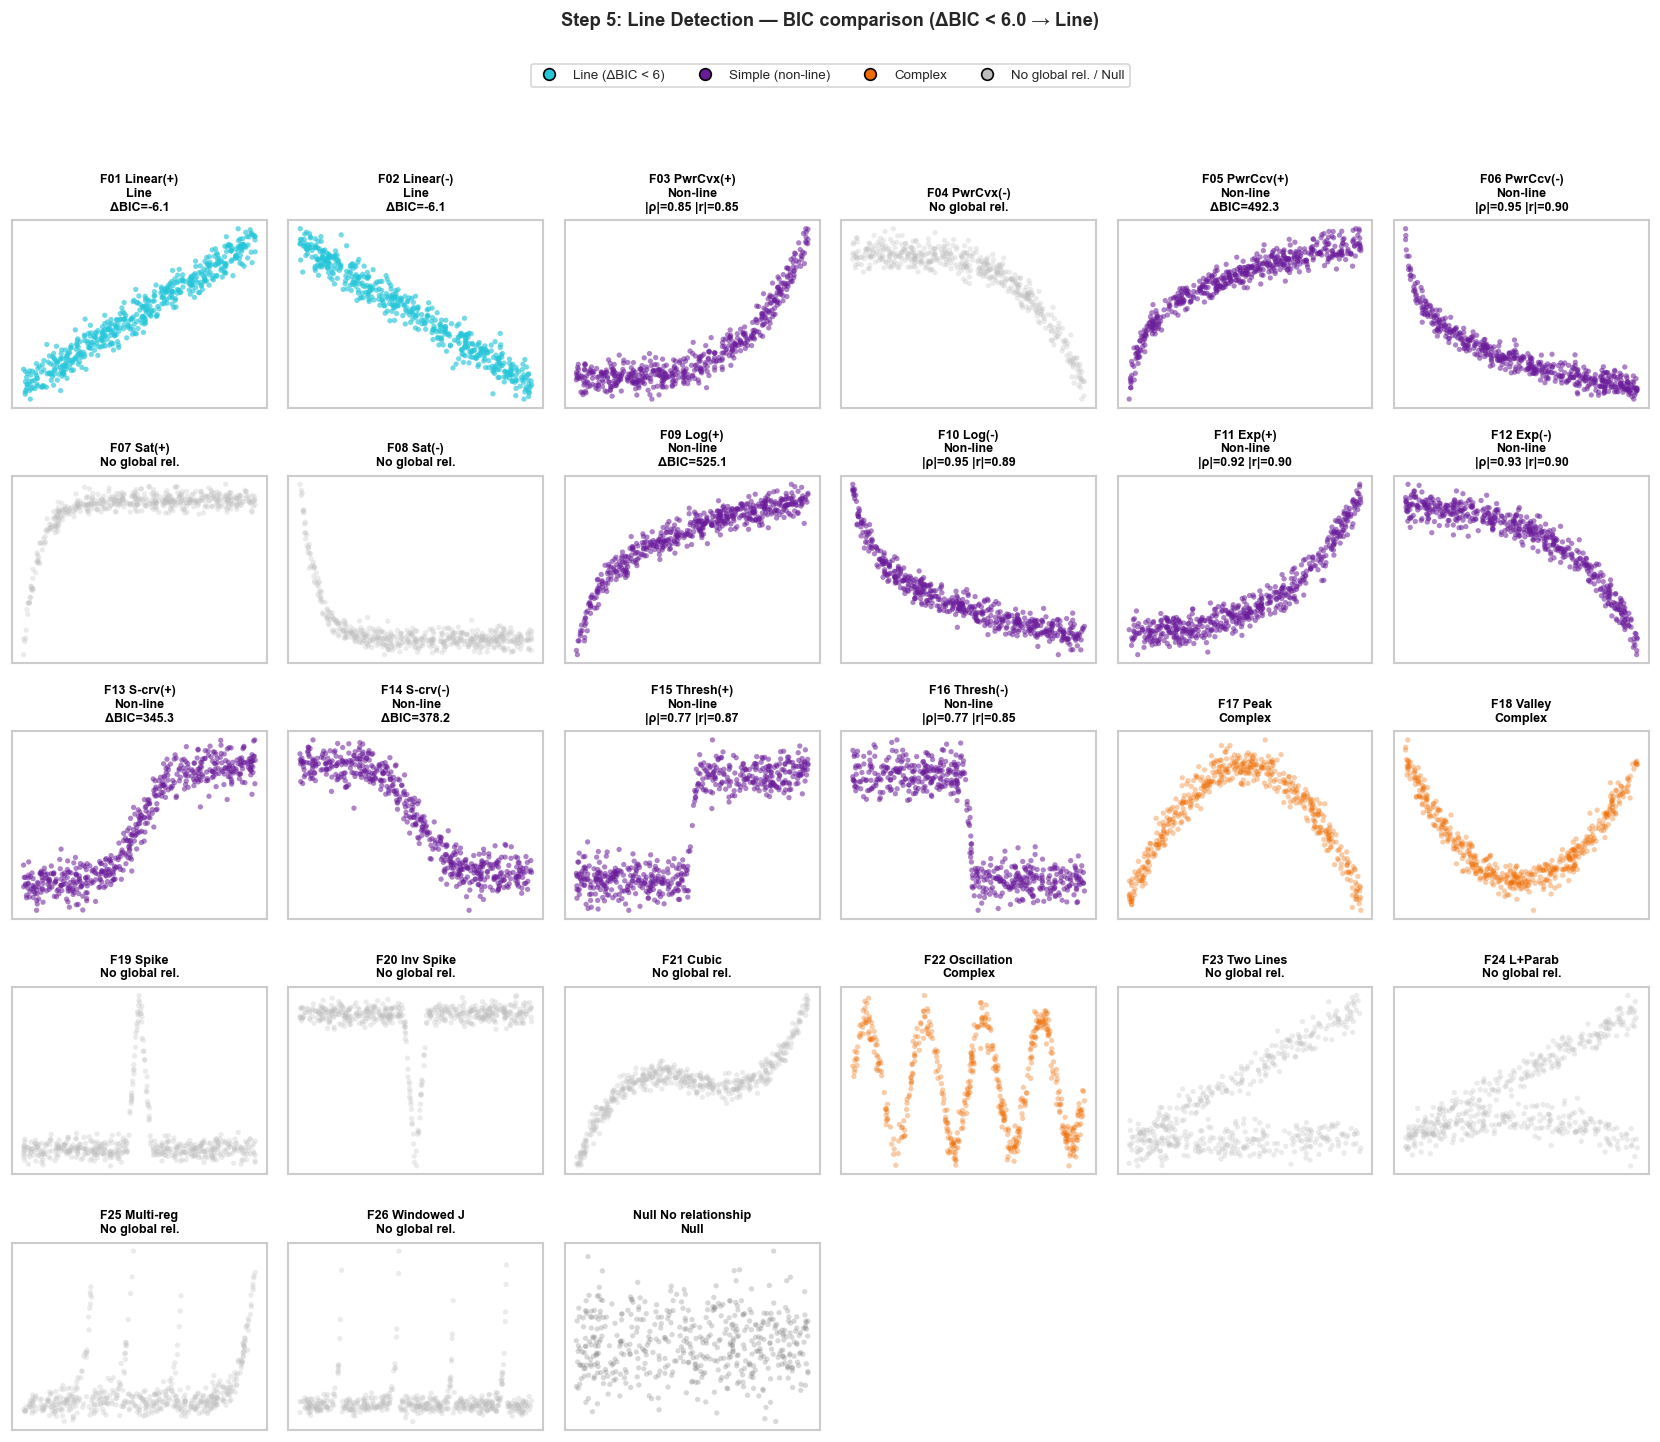

In [20]:
# ── Plot Step 5: Line Detection (BIC) ──
cases_27 = cases_27.drop(columns=['is_line', 'delta_bic', 'r2_1', 'r2_3'], errors='ignore')
cases_27 = cases_27.merge(
    simple_cases_27[['case_id', 'is_line', 'delta_bic', 'r2_1', 'r2_3']],
    on='case_id', how='left')

fig, axes = plt.subplots(5, 6, figsize=(14, 12))
fig.suptitle(f'Step 5: Line Detection — BIC comparison (ΔBIC < {DELTA_BIC_THRESH} → Line)',
             fontsize=11, fontweight='bold', y=1.0)

for ax, (_, row) in zip(axes.flat, cases_27.iterrows()):
    idx = case_idx_by_id.get(row['case_id'])
    if row['simple_complex_label'] == 'Simple':
        if row['is_line'] == True:
            label, color, alpha = 'Line', C_LINE, 0.65
        else:
            label, color, alpha = 'Non-line', C_NONLINE, 0.55
    elif row['simple_complex_label'] == 'Complex':
        label, color, alpha = 'Complex', C_COMPLEX, 0.35
    elif row['family_id'] == 'Null':
        label, color, alpha = 'Null', C_NULL, 0.30
    else:
        label, color, alpha = 'No global rel.', C_NO_REL, 0.30

    if idx is not None:
        ax.scatter(x_all[idx], y_all[idx], s=10, alpha=alpha, color=color, edgecolors='none')

    fid = row['family_id']
    short = row['short']
    dbic = row.get('delta_bic', float('nan'))
    if row['simple_complex_label'] == 'Simple' and pd.notna(dbic):
        ax.set_title(f"{fid} {short}\n{label}\nΔBIC={dbic:.1f}",
                     fontsize=7.5, fontweight='bold', color='black')
    elif row['simple_complex_label'] == 'Simple':
        rho = abs(row['spearman_rho'])
        r = abs(row['pearson_r'])
        ax.set_title(f"{fid} {short}\n{label}\n|ρ|={rho:.2f} |r|={r:.2f}",
                     fontsize=7.5, fontweight='bold', color='black')
    else:
        ax.set_title(f"{fid} {short}\n{label}",
                     fontsize=7.5, fontweight='bold', color='black')
    ax.set_xticks([]); ax.set_yticks([])

for ax in axes.flat[len(cases_27):]:
    ax.set_visible(False)

handles = [Line2D([0],[0], marker='o', color='none', markerfacecolor=c, markersize=7, label=k)
           for k, c in [('Line (ΔBIC < 6)', C_LINE), ('Simple (non-line)', C_NONLINE),
                         ('Complex', C_COMPLEX), ('No global rel. / Null', C_NO_REL)]]
fig.legend(handles=handles, loc='upper center', ncol=4, fontsize=8, frameon=True, bbox_to_anchor=(0.5, 0.968))
plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.savefig(OUT_DIR / '27plot_step5_polyfit.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 6 — Curvature Type (Polyfit)

Base: all Simple cases **minus Line**. Step 6 only assigns monotonic nonlinear curvature types:

| f′(x) pattern | f″(x) pattern | Curvature Type |
|---|---|---|
| Maintains same sign | Constant positive | **Convex** |
| Maintains same sign | Constant negative | **Concave** |
| Maintains same sign | Changes sign once | **Inflected / S-shaped** |
| Unexpected pattern | any | **Curvature uncertain** (with a diagnostic reason) |

U-shape / inverted-U / structural complex relationships belong to Step 2. If they appear here, Step 6 reports **Curvature uncertain** instead of creating another shape class.

In [21]:
# ── Step 6: Curvature Type (Polyfit on non-line cases) ──
non_line_27 = simple_cases_27[~simple_cases_27['is_line']].copy()

# Run polyfit (cubic + derivative analysis) on non-line cases only
polyfit_results = {}
for _, row in non_line_27.iterrows():
    idx = _cidx[row['case_id']]
    res = polyfit_classify(_x_all[idx], _y_all[idx])
    polyfit_results[row['case_id']] = res

non_line_27['polyfit_shape'] = non_line_27['case_id'].map(
    lambda cid: polyfit_results[cid]['shape'])
non_line_27['polyfit_r2'] = non_line_27['case_id'].map(
    lambda cid: polyfit_results[cid]['r2_3'])
non_line_27['polyfit_logistic'] = non_line_27['case_id'].map(
    lambda cid: polyfit_results[cid]['logistic_used'])
non_line_27['f1_sign_changes'] = non_line_27['case_id'].map(
    lambda cid: polyfit_results[cid]['n_f1_sign_changes'])
non_line_27['f2_sign_changes'] = non_line_27['case_id'].map(
    lambda cid: polyfit_results[cid]['n_f2_sign_changes'])
non_line_27['f2_dominance'] = non_line_27['case_id'].map(
    lambda cid: polyfit_results[cid]['f2_dominance'])

CURVATURE_DISPLAY = {
    'convex': 'Convex',
    'concave': 'Concave',
    'inflected': 'Inflected',
}
UNCERTAIN_REASON = {
    'linear': 'line-disagreement',
    'U-shape': 'monotonicity-disagreement',
    'inverted-U': 'monotonicity-disagreement',
    'complex': 'cubic-complex / logistic-failed',
}
non_line_27['shape_tree'] = non_line_27['polyfit_shape'].map(
    lambda s: CURVATURE_DISPLAY.get(s, 'Curvature uncertain'))
non_line_27['curvature_uncertain_reason'] = non_line_27['polyfit_shape'].map(
    lambda s: '' if s in CURVATURE_DISPLAY else UNCERTAIN_REASON.get(s, 'unexpected-polyfit-output'))

# Write back
simple_cases_27['shape_tree'] = 'Line'
simple_cases_27['curvature_uncertain_reason'] = ''
simple_cases_27.loc[non_line_27.index, 'shape_tree'] = non_line_27['shape_tree']
simple_cases_27.loc[non_line_27.index, 'curvature_uncertain_reason'] = non_line_27['curvature_uncertain_reason']
for col in ['polyfit_shape', 'polyfit_r2', 'polyfit_logistic',
            'f1_sign_changes', 'f2_sign_changes', 'f2_dominance']:
    if col not in simple_cases_27.columns:
        simple_cases_27[col] = np.nan
    simple_cases_27.loc[non_line_27.index, col] = non_line_27[col]

print('═══ Step 6: Curvature Type (Polyfit Derivatives) ═══')
print('Classify Simple non-line cases by f\'/f\'\'; unexpected patterns become Curvature uncertain:')
print('  f\' same sign + f\'\' constant pos   → Convex')
print('  f\' same sign + f\'\' constant neg   → Concave')
print('  f\' same sign + f\'\' changes sign   → Inflected')
print('  unexpected derivative pattern       → Curvature uncertain')
print(f'\nBase: Non-Line Simple — {len(non_line_27)} / {len(simple_cases_27)} simple')
print()
print(simple_cases_27['shape_tree'].value_counts().to_string())
print()

display(simple_cases_27[[
    'family_id', 'short', 'direction_tree', 'monotonicity_tree',
    'is_line', 'polyfit_shape', 'f1_sign_changes', 'f2_sign_changes',
    'f2_dominance', 'polyfit_r2', 'polyfit_logistic', 'shape_tree',
    'curvature_uncertain_reason',
]].round(4))

═══ Step 6: Curvature Type (Polyfit Derivatives) ═══
Classify Simple non-line cases by f'/f''; unexpected patterns become Curvature uncertain:
  f' same sign + f'' constant pos   → Convex
  f' same sign + f'' constant neg   → Concave
  f' same sign + f'' changes sign   → Inflected
  unexpected derivative pattern       → Curvature uncertain

Base: Non-Line Simple — 11 / 13 simple

shape_tree
Convex       4
Inflected    4
Concave      3
Line         2



,family_id,short,direction_tree,monotonicity_tree,is_line,polyfit_shape,f1_sign_changes,f2_sign_changes,f2_dominance,polyfit_r2,polyfit_logistic,shape_tree,curvature_uncertain_reason
0,F01,Linear(+),Positive,Strong,True,NaN,NaN,NaN,NaN,NaN,NaN,Line,
1,F02,Linear(-),Negative,Strong,True,NaN,NaN,NaN,NaN,NaN,NaN,Line,
2,F03,PwrCvx(+),Positive,Med,False,convex,0.0,1.0,0.9799,0.9501,False,Convex,
4,F05,PwrCcv(+),Positive,Strong,False,concave,0.0,1.0,0.8622,0.9349,False,Concave,
5,F06,PwrCcv(-),Negative,Strong,False,convex,0.0,1.0,0.8578,0.9311,False,Convex,
8,F09,Log(+),Positive,Strong,False,concave,0.0,1.0,0.8774,0.9373,False,Concave,
9,F10,Log(-),Negative,Strong,False,convex,0.0,1.0,0.8398,0.9383,False,Convex,
10,F11,Exp(+),Positive,Strong,False,convex,0.0,1.0,0.9917,0.9542,False,Convex,
11,F12,Exp(-),Negative,Strong,False,concave,0.0,1.0,0.9780,0.9537,False,Concave,
12,F13,S-crv(+),Positive,Strong,False,inflected,2.0,1.0,0.5086,0.9335,True,Inflected,


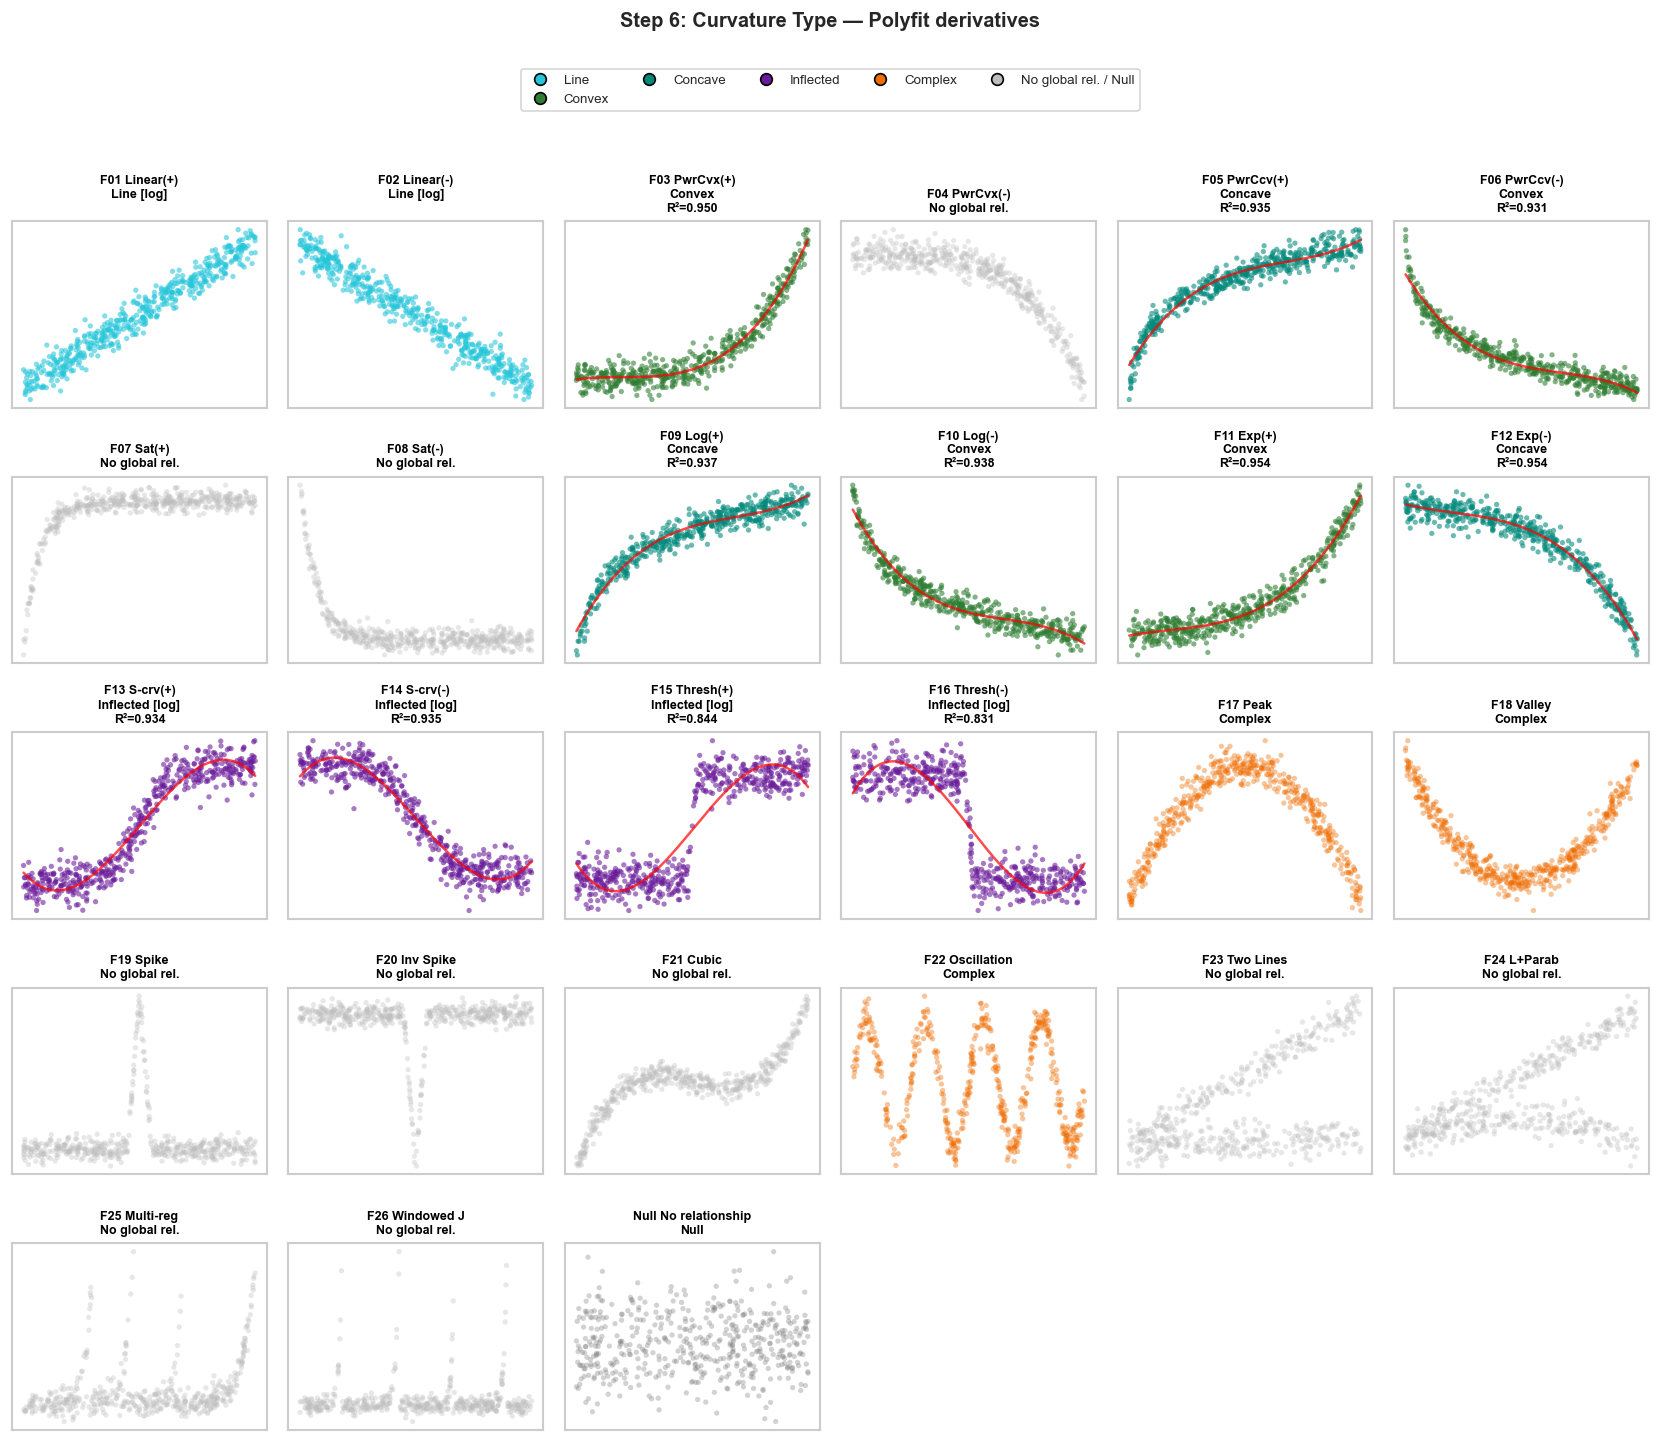

In [22]:
# ── Plot Step 6: Curvature Type (Polyfit) ──
for col in ['shape_tree', 'polyfit_logistic', 'polyfit_r2', 'curvature_uncertain_reason']:
    cases_27 = cases_27.drop(columns=[col], errors='ignore')
cases_27 = cases_27.merge(
    simple_cases_27[['case_id', 'shape_tree', 'polyfit_logistic', 'polyfit_r2',
                     'curvature_uncertain_reason']],
    on='case_id', how='left')

SHAPE_MAP = {
    'Line': C_LINE, 'Convex': C_CONVEX, 'Concave': C_CONCAVE,
    'Inflected': C_INFLECTED, 'Curvature uncertain': C_WEAK,
}

fig, axes = plt.subplots(5, 6, figsize=(14, 12))
fig.suptitle('Step 6: Curvature Type — Polyfit derivatives',
             fontsize=12, fontweight='bold', y=1.0)

for ax, (_, row) in zip(axes.flat, cases_27.iterrows()):
    idx = case_idx_by_id.get(row['case_id'])
    if row['simple_complex_label'] == 'Simple':
        label = row['shape_tree']
        color = SHAPE_MAP.get(label, C_WEAK)
        alpha = 0.58
    elif row['simple_complex_label'] == 'Complex':
        label, color, alpha = 'Complex', C_COMPLEX, 0.40
    elif row['family_id'] == 'Null':
        label, color, alpha = 'Null', C_NULL, 0.35
    else:
        label, color, alpha = 'No global rel.', C_NO_REL, 0.35

    if idx is not None:
        ax.scatter(x_all[idx], y_all[idx], s=10, alpha=alpha, color=color, edgecolors='none')
        if row['simple_complex_label'] == 'Simple' and row['case_id'] in polyfit_results:
            res = polyfit_results[row['case_id']]
            ax.plot(res['x_grid'], res['f_grid'], color='red', lw=1.5, alpha=0.7)

    fid = row['family_id']
    short = row['short']
    if row['simple_complex_label'] == 'Simple':
        logistic_tag = ' [log]' if row.get('polyfit_logistic') else ''
        r2 = row.get('polyfit_r2', float('nan'))
        r2_str = f"R²={r2:.3f}" if pd.notna(r2) else ''
        ax.set_title(f"{fid} {short}\n{label}{logistic_tag}\n{r2_str}",
                     fontsize=7.5, fontweight='bold', color='black')
    else:
        ax.set_title(f"{fid} {short}\n{label}",
                     fontsize=7.5, fontweight='bold', color='black')
    ax.set_xticks([]); ax.set_yticks([])

for ax in axes.flat[len(cases_27):]:
    ax.set_visible(False)

shape_legend = [(k, SHAPE_MAP[k]) for k in SHAPE_MAP if k in set(cases_27['shape_tree'].dropna())]
shape_legend += [('Complex', C_COMPLEX), ('No global rel. / Null', C_NO_REL)]
handles = [Line2D([0],[0], marker='o', color='none', markerfacecolor=c, markersize=7, label=k)
           for k, c in shape_legend]
fig.legend(handles=handles, loc='upper center', ncol=min(5, len(handles)),
           fontsize=8, frameon=True, bbox_to_anchor=(0.5, 0.965))
plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.savefig(OUT_DIR / '27plot_step6_polyfit.png', dpi=150, bbox_inches='tight')
plt.show()

## Final — Combined Tree Result

Global → Simple/Complex → Direction → Monotonicity → Line Detection (polyfit) → Curvature Type (polyfit)

In [23]:
# ── Final tree label ──
cases_27['final_tree_label'] = np.select(
    [cases_27['family_id'] == 'Null',
     cases_27['simple_complex_label'] == 'No global relationship',
     cases_27['simple_complex_label'] == 'Complex',
     cases_27['simple_complex_label'] == 'Simple'],
    ['Null', 'No global relationship', 'Complex',
     cases_27['shape_tree'].fillna('Simple: unclassified')],
    default='Unclassified'
)

print('═══ Final Tree Classification ═══')
print(cases_27['final_tree_label'].value_counts(dropna=False).to_string())

═══ Final Tree Classification ═══
final_tree_label
No global relationship    10
Convex                     4
Inflected                  4
Concave                    3
Complex                    3
Line                       2
Null                       1


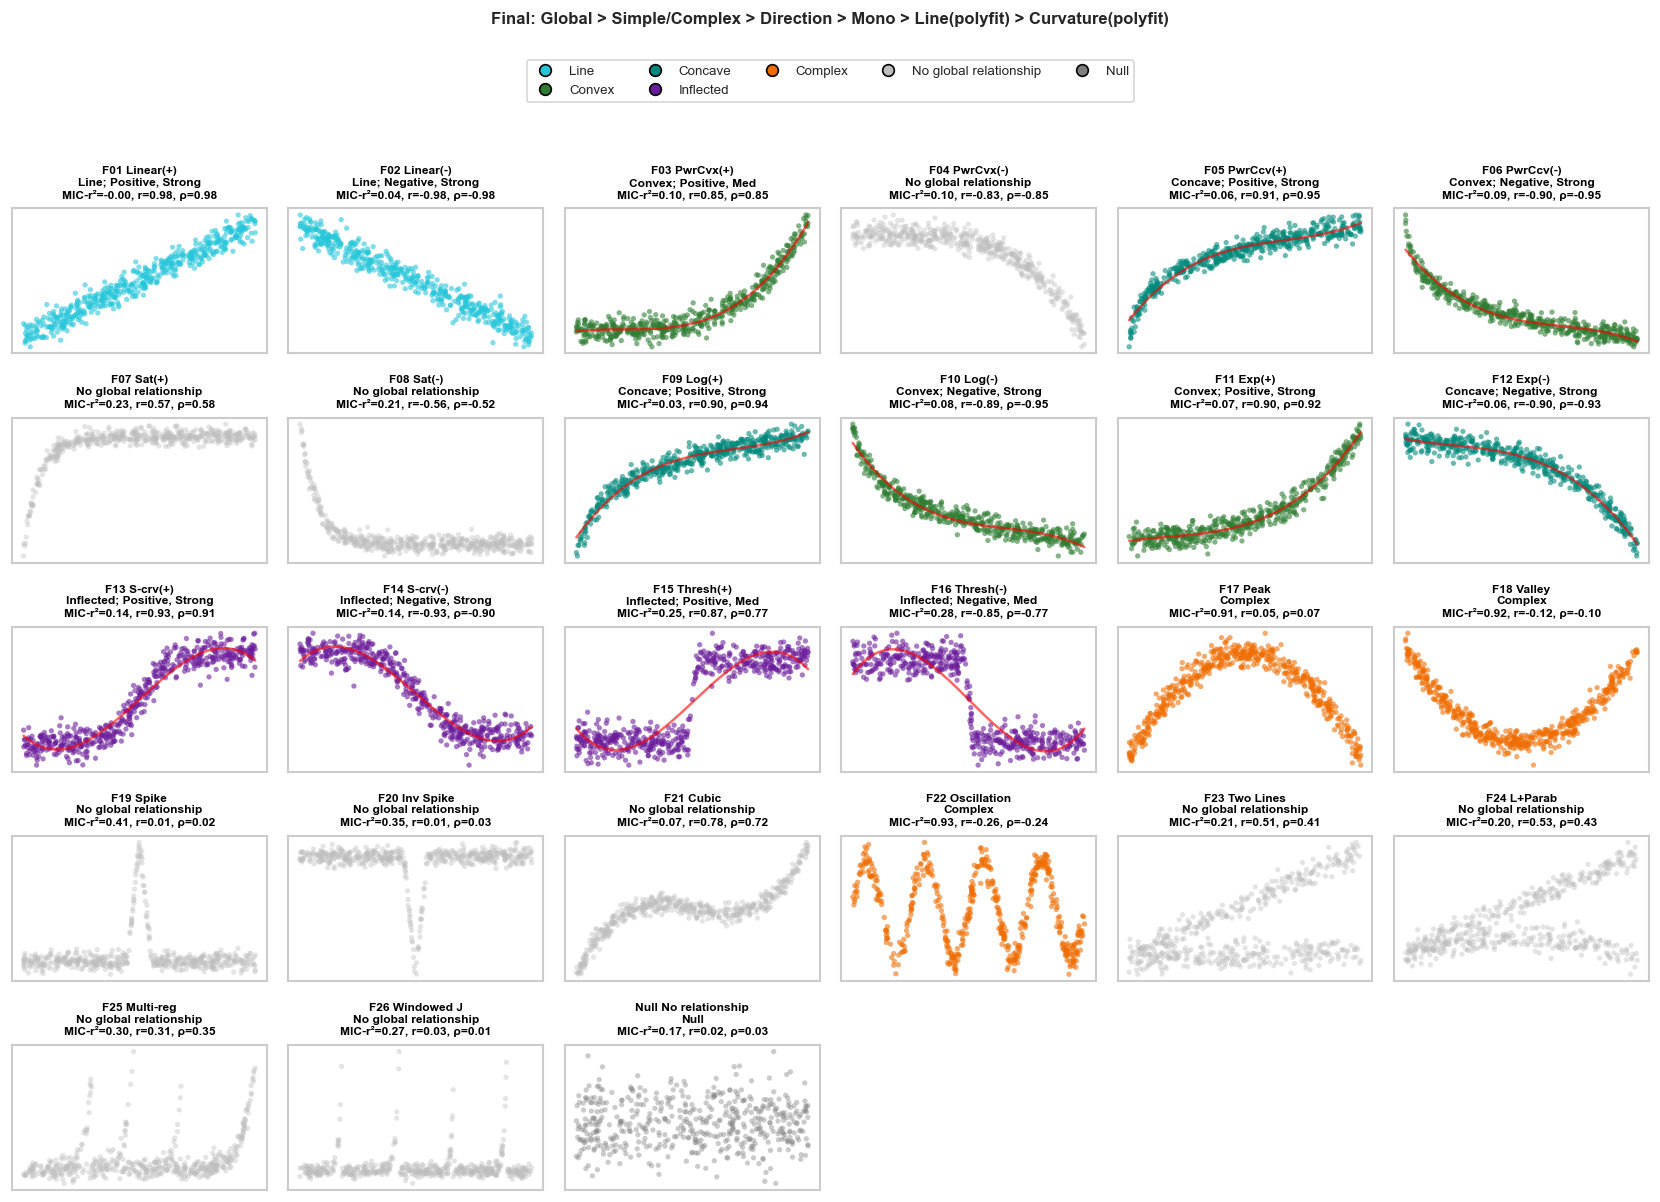

In [24]:
# ── Plot Final: Combined tree result ──
FINAL_MAP = {
    'Line': C_LINE, 'Convex': C_CONVEX, 'Concave': C_CONCAVE,
    'Inflected': C_INFLECTED, 'Curvature uncertain': C_WEAK,
    'Simple: unclassified': C_WEAK,
    'Complex': C_COMPLEX, 'No global relationship': C_NO_REL, 'Null': C_NULL,
}

fig, axes = plt.subplots(5, 6, figsize=(14, 10))
fig.suptitle('Final: Global > Simple/Complex > Direction > Mono > Line(polyfit) > Curvature(polyfit)',
             fontsize=10, fontweight='bold', y=1.0)

for ax, (_, row) in zip(axes.flat, cases_27.iterrows()):
    idx = case_idx_by_id.get(row['case_id'])
    label = row['final_tree_label']
    color = FINAL_MAP.get(label, '#424242')
    alpha = 0.58 if label not in ['No global relationship', 'Null'] else 0.40

    if idx is not None:
        ax.scatter(x_all[idx], y_all[idx], s=10, alpha=alpha, color=color, edgecolors='none')
        if row['simple_complex_label'] == 'Simple' and row['case_id'] in polyfit_results:
            res = polyfit_results[row['case_id']]
            ax.plot(res['x_grid'], res['f_grid'], color='red', lw=1.5, alpha=0.6)

    fid = row['family_id']
    short = row['short']
    if row['simple_complex_label'] == 'Simple':
        subtitle = label + '; ' + str(row.get('direction_tree','')) + ', ' + str(row.get('monotonicity_tree',''))
    else:
        subtitle = label

    mr = row['MIC_minus_r2']
    r = row['pearson_r']
    rho = row['spearman_rho']
    ax.set_title(f"{fid} {short}\n{subtitle}\nMIC-r²={mr:.2f}, r={r:.2f}, ρ={rho:.2f}",
                 fontsize=7.2, fontweight='bold', color='black')
    ax.set_xticks([]); ax.set_yticks([])

for ax in axes.flat[len(cases_27):]:
    ax.set_visible(False)

handles = [Line2D([0],[0], marker='o', color='none', markerfacecolor=FINAL_MAP[k], markersize=7, label=k)
           for k in FINAL_MAP if k in set(cases_27['final_tree_label'])]
fig.legend(handles=handles, loc='upper center', ncol=min(5, len(handles)),
           fontsize=8, frameon=True, bbox_to_anchor=(0.5, 0.965))
plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.savefig(OUT_DIR / '27plot_final_polyfit.png', dpi=150, bbox_inches='tight')
plt.show()

In [25]:
# ── Final classification summary ──
summary_cols = [
    'family_id', 'short', 'global_label', 'simple_complex_label',
    'direction_tree', 'monotonicity_tree', 'is_line',
    'polyfit_shape', 'polyfit_r2', 'shape_tree', 'curvature_uncertain_reason',
    'final_tree_label',
    'MIC', 'distance_correlation', 'MIC_minus_r2',
    'pearson_r', 'spearman_rho',
]

existing = [c for c in summary_cols if c in cases_27.columns]
display(cases_27[existing].round(3))

,family_id,short,global_label,simple_complex_label,direction_tree,monotonicity_tree,is_line,polyfit_r2,shape_tree,curvature_uncertain_reason,final_tree_label,MIC,distance_correlation,MIC_minus_r2,pearson_r,spearman_rho
0,F01,Linear(+),Global relationship,Simple,Positive,Strong,True,NaN,Line,,Line,0.950,0.972,-0.002,0.976,0.977
1,F02,Linear(-),Global relationship,Simple,Negative,Strong,True,NaN,Line,,Line,0.988,0.974,0.036,-0.976,-0.975
2,F03,PwrCvx(+),Global relationship,Simple,Positive,Med,False,0.950,Convex,,Convex,0.834,0.884,0.105,0.854,0.852
3,F04,PwrCvx(-),No global relationship,No global relationship,NaN,NaN,NaN,NaN,NaN,NaN,No global relationship,0.790,0.857,0.101,-0.830,-0.850
4,F05,PwrCcv(+),Global relationship,Simple,Positive,Strong,False,0.935,Concave,,Concave,0.885,0.932,0.063,0.906,0.951
5,F06,PwrCcv(-),Global relationship,Simple,Negative,Strong,False,0.931,Convex,,Convex,0.895,0.931,0.089,-0.898,-0.952
6,F07,Sat(+),No global relationship,No global relationship,NaN,NaN,NaN,NaN,NaN,NaN,No global relationship,0.558,0.629,0.229,0.574,0.583
7,F08,Sat(-),No global relationship,No global relationship,NaN,NaN,NaN,NaN,NaN,NaN,No global relationship,0.527,0.603,0.208,-0.564,-0.518
8,F09,Log(+),Global relationship,Simple,Positive,Strong,False,0.937,Concave,,Concave,0.846,0.927,0.030,0.903,0.941
9,F10,Log(-),Global relationship,Simple,Negative,Strong,False,0.938,Convex,,Convex,0.879,0.925,0.080,-0.894,-0.953
